# Installation and configuration of IBL packages

In [1]:
!pip install --quiet ONE-api
!pip install --quiet ibllib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.6/442.6 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.1/226.1

In [2]:
# When running in jupyter set number of threads to 1
import os
os.environ.setdefault('ONE_HTTP_DL_THREADS', '1')

from one.api import ONE
ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
one = ONE(password='international')

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


In [3]:
# Suppress some future warnings
import warnings
warnings.simplefilter("ignore", FutureWarning)

# Change the load method depending on python version
from one.remote.aws import s3_download_file, get_s3_public
import pandas as pd
import sys
python_ver = sys.version_info

if python_ver >= (3, 10):
    from one.alf.path import add_uuid_string
else:
    from one.alf.files import add_uuid_string

s3, bucket = get_s3_public()

def load_aggregate(subject, dataset):
    if sys.version_info >= (3, 10):
        return one.load_aggregate('subjects', subject, dataset)
    else:
        files = one.list_aggregates('subjects', subject, dataset=dataset)
        files = files.iloc[0]
        src_path = str(add_uuid_string(files['rel_path'], files.name))
        dst_path = one.cache_dir.joinpath(files['rel_path'])
        local_file = s3_download_file(src_path, dst_path, s3=s3, bucket_name=bucket)
        return pd.read_parquet(local_file)

# Finding subjects with training data

In [4]:
import numpy as np

# Find all aggregate training datasets from IBL behaviour paper
datasets = one.alyx.rest('datasets', 'list', tag='2021_Q1_IBL_et_al_Behaviour', name='_ibl_subjectTrials.table.pqt')

# Find the subject name from the info stored in the relative path
subjects = np.unique([d['file_records'][0]['relative_path'].split('/')[2] for d in datasets])

# Loading trials data for a single subject

In [5]:
# Load in the subjectTrials table and sessionTrials table for the first subject
subject = subjects[0]
subject_trials = load_aggregate(subject, '_ibl_subjectTrials.table.pqt')
session_trials = load_aggregate(subject, '_ibl_subjectSessions.table.pqt')

# Add in lab, task_protocol, subject name information from the sessions table
if 'task_protocol' in subject_trials:
    subject_trials = subject_trials.drop('task_protocol', axis=1)
subject_trials = subject_trials.set_index('session').join(session_trials.drop('date', axis=1))

/usr/local/lib/python3.12/dist-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL045/#2024-04-10#/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL045/#2024-04-10#/_ibl_subjectTrials.table.pqt: 100%|██████████| 9.27M/9.27M [00:01<00:00, 6.45MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL045/_ibl_subjectSessions.table.pqt: 100%|██████████| 8.98k/8.98k [00:00<00:00, 26.6kB/s]


The `subject_trials` table contains all the trials data for each training session collected in the subject. See [here](https://docs.google.com/document/d/1OqIqqakPakHXRAwceYLwFY9gOrm8_P62XIfCTnHwstg/edit#heading=h.ls81qq9ihg4x) for more information about this dataset.

We can find the number of sessions collected, or the number of times the subject was run under a specific task protocol

In [6]:
# Find the number of sessions for this subject
n_sessions = subject_trials.index.unique().size
print(f'Subject {subject} has {n_sessions} sessions')

# Find the number of times a task protocol was run
n_protocols = subject_trials[~subject_trials.index.duplicated()].task_protocol.value_counts()
print(n_protocols)

Subject CSHL045 has 76 sessions
task_protocol
_iblrig_tasks_biasedChoiceWorld6.3.1      17
_iblrig_tasks_trainingChoiceWorld6.1.3    14
_iblrig_tasks_trainingChoiceWorld6.2.5    12
_iblrig_tasks_trainingChoiceWorld6.3.1    11
_iblrig_tasks_biasedChoiceWorld6.2.5       6
_iblrig_tasks_ephysChoiceWorld6.2.5        3
_iblrig_tasks_trainingChoiceWorld6.2.4     3
_iblrig_tasks_trainingChoiceWorld6.0.6     3
_iblrig_tasks_trainingChoiceWorld6.2.1     2
_iblrig_tasks_ephysChoiceWorld6.4.0        2
_iblrig_tasks_trainingChoiceWorld6.2.0     1
_iblrig_tasks_trainingChoiceWorld6.1.1     1
_iblrig_tasks_trainingChoiceWorld6.1.2     1
Name: count, dtype: int64


We can get the trials data for an individual session of choice, here a the first session using the biasedChoiceWorld protocol

In [7]:
# Get the trials data for a single session
# Find a session run under biasedChoiceWorld
sess = subject_trials[subject_trials['task_protocol'].str.contains('biasedChoiceWorld')].index.unique()[0]
trials = subject_trials[subject_trials.index == sess]

Using this data we can plot the psychometric curve and compute some performance metrics, for example the number of trials in the session or the performance of the mouse on easy trials (50% and 100% contrast)

Number of trials for session a4f7079b-d157-4de9-ba80-de9a98f35c8b: 682
Performance easy for session a4f7079b-d157-4de9-ba80-de9a98f35c8b: 0.9457364341085271


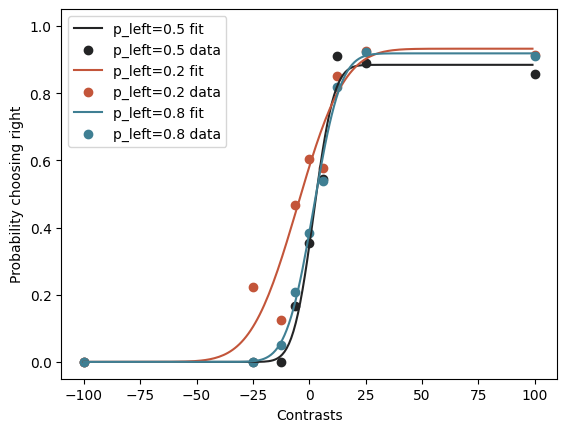

In [8]:
from brainbox.behavior.training import plot_psychometric, compute_n_trials, compute_performance_easy, compute_performance

plot_psychometric(trials)
n_trials = compute_n_trials(trials)
perf_easy = compute_performance_easy(trials)
print(f'Number of trials for session {sess}: {n_trials}')
print(f'Performance easy for session {sess}: {perf_easy}')

## Combining training criteria

Another [dataset](https://docs.google.com/document/d/1OqIqqakPakHXRAwceYLwFY9gOrm8_P62XIfCTnHwstg/edit#heading=h.18vu2zskyq0r) is available that contains information about the session at which the subject reached certain training criteria in the IBL training pipeline. More information can be found about the training pipeline in the study [A standardized and reproducible method to measure decision-making in mice](https://doi.org/10.1101/2020.01.17.909838).

We can download this dataset in the following way

In [9]:
subject_training = load_aggregate(subject, '_ibl_subjectTraining.table.pqt')

(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL045/#2024-08-21#/_ibl_subjectTraining.table.pqt: 100%|██████████| 3.27k/3.27k [00:00<00:00, 8.41kB/s]


We can combine this with our subject trials table to see how the subject progressed

In [10]:
subject_trials = (subject_trials
          .join(subject_training.set_index('session'))
          .sort_values(by=['session_start_time', 'intervals_0']))
subject_trials['training_status'] = subject_trials.training_status.fillna(method='ffill')

Our subject trials table now has a new column that indicates the training criteria of the mouse at each session. We can use this information to make a plot of how the performance of the mouse improved across training days.

We will need to compute the performance per session and add this column to our dataframe and also add in a column for training day.

In [11]:
sessions = subject_trials.index.unique()
for n_sess, sess in enumerate(sessions):
  trials = subject_trials[subject_trials.index == sess]
  perf_easy = compute_performance_easy(trials)
  subject_trials.loc[subject_trials.index == sess, 'performance_easy'] = perf_easy
  subject_trials.loc[subject_trials.index == sess, 'training_day'] = n_sess

Note since we already ordered by session_start_time above our table was already sorted. Here we have simply assigned each training session to a training day but there are some cases where multiple training sessions were run on the same day so this may be something you want to account for in your analysis.

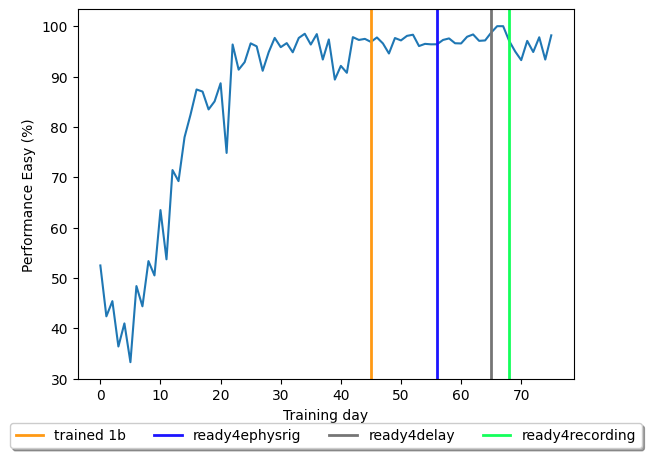

In [12]:
import matplotlib.pyplot as plt
from ibllib.pipes.training_status import TRAINING_STATUS
fig, ax = plt.subplots(1, 1)
ax.plot(subject_trials['training_day'], subject_trials['performance_easy'] * 100)
ax.set_xlabel("Training day")
ax.set_ylabel("Performance Easy (%)")
status = subject_trials.drop_duplicates(subset='training_status', keep='first')
for _, st in status.iterrows():
    if st['training_status'] in ['untrainable', 'unbiasable']:
        continue
    if TRAINING_STATUS[st['training_status']][0] <= 0:
        continue
    ax.axvline(st['training_day'], linewidth=2,
               color=np.array(TRAINING_STATUS[st['training_status']][1]) / 255, label=st['training_status'])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
                   fancybox=True, shadow=True, ncol=5)

# Combining data across multiple subjects

We can loop over all the subjects available to get a large dataframe that contains the data for all the subjects. Here is an example of how this can be done


In [13]:
import pandas as pd

all_trials = []

# Download two tables, subject trials table and subject training table and combine
for i, subject in enumerate(subjects):
  if np.mod(i, 50) == 0:
    print(f'{i}/{len(subjects)}')

  # Load trials table for subject
  subject_trials = load_aggregate(subject, '_ibl_subjectTrials.table.pqt')

  # Load sessions table for subject
  session_trials = load_aggregate(subject, '_ibl_subjectSessions.table.pqt')

  # Load training status for subject
  subject_training = load_aggregate(subject, '_ibl_subjectTraining.table.pqt')

  # Combine the two tables
  subject_trials = (subject_trials
            .set_index('session')
            .join(subject_training.set_index('session'))
            .sort_values(by=['session_start_time', 'intervals_0']))
  subject_trials['training_status'] = subject_trials.training_status.fillna(method='ffill')

  # Join sessions table for number, task_protocol, etc.
  if 'task_protocol' in subject_trials:
      subject_trials = subject_trials.drop('task_protocol', axis=1)
  subject_trials = subject_trials.join(session_trials.drop('date', axis=1))

  # Sort the trials by session start time and trial number
  subject_trials = subject_trials.sort_values(by=['session_start_time', 'intervals_0'])


  # add in extra columns for performance easy and training day
  sessions = subject_trials.index.unique()
  for n_sess, sess in enumerate(sessions):
    trials = subject_trials[subject_trials.index == sess]
    perf_easy = compute_performance_easy(trials)
    subject_trials.loc[subject_trials.index == sess, 'performance_easy'] = perf_easy
    subject_trials.loc[subject_trials.index == sess, 'training_day'] = n_sess


  all_trials.append(subject_trials)

all_trials = pd.concat(all_trials)

0/140


/usr/local/lib/python3.12/dist-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL045/#2024-04-10#/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL046/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL046/#2024-08-21#/_ibl_subjectTrials.table.pqt: 100%|██████████| 11.1M/11.1M [00:01<00:00, 8.46MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL046/_ibl_subjectSessions.table.pqt: 100%|██████████| 10.2k/10.2k [00:00<00:00, 39.3kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL046/_ibl_subjectTraining.table.pqt: 100%|██████████| 3.26k/3.26k [00:00<00:00, 14.4kB/s]

Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL_001/_ibl_subjectSessions.table.9291b9e8-d1eb-4952-a780-f71e00250d1b.pqt Bytes: 9424


100%|██████████| 0.0089874267578125/0.0089874267578125 [00:00<00:00, 18.14it/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL_001/#2024-08-21#/_ibl_subjectTraining.table.pqt: 100%|██████████| 3.19k/3.19k [00:00<00:00, 12.7kB/s]
/usr/local/lib/python3.12/dist-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL_002/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL_002/#2024-08-21#/_ibl_subjectTrials.table.pqt: 100%|██████████| 9.16M/9.16M [00:01<00:00, 8.37MB/s]


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL_002/_ibl_subjectSessions.table.37b5f24f-84df-4e3c-8286-6699891f8c3c.pqt Bytes: 9364


...

100%|██████████| 0.007701873779296875/0.007701873779296875 [00:00<00:00, 18.12it/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mrsicflogellab/IBL_001/_ibl_subjectTraining.table.pqt: 100%|██████████| 3.13k/3.13k [00:00<00:00, 10.6kB/s]
/usr/local/lib/python3.12/dist-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/mrsicflogellab/IBL_002/#2024-08-21#/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mrsicflogellab/IBL_002/#2024-08-21#/_ibl_subjectTrials.table.pqt: 100%|██████████| 4.67M/4.67M [00:00<00:00, 4.69MB/s]


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mrsicflogellab/IBL_002/_ibl_subjectSessions.table.9ac5f6f9-78b4-44a5-afe6-a2379ed6062c.pqt Bytes: 7968


100%|██████████| 0.007598876953125/0.007598876953125 [00:00<00:00, 13.59it/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mrsicflogellab/IBL_002/_ibl_subjectTraining.table.pqt: 100%|██████████| 3.08k/3.08k [00:00<00:00, 11.9kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/cortexlab/KS002/_ibl_subjectTrials.table.pqt: 100%|██████████| 7.58M/7.58M [00:01<00:00, 6.73MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/cortexlab/KS002/_ibl_subjectSessions.table.pqt: 100%|██████████| 9.53k/9.53k [00:00<00:00, 38.3kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/cortexlab/KS002/_ibl_subjectTraining.table.pqt: 100%|██████████| 3.26k/3.26k [00:00<00:00, 11.4kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/cortexlab/KS004/_ibl_subjectTrials.table.pqt: 100%|██████████| 4.52M/4.52M [00:01<00:00, 4.46MB/s]
(S3) /root/Dow

100/140


(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mainenlab/ZM_1092/_ibl_subjectTrials.table.pqt: 100%|██████████| 1.57M/1.57M [00:00<00:00, 2.01MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mainenlab/ZM_1092/_ibl_subjectSessions.table.pqt: 100%|██████████| 6.52k/6.52k [00:00<00:00, 27.3kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mainenlab/ZM_1092/_ibl_subjectTraining.table.pqt: 100%|██████████| 3.08k/3.08k [00:00<00:00, 11.8kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mainenlab/ZM_1093/_ibl_subjectTrials.table.pqt: 100%|██████████| 1.28M/1.28M [00:00<00:00, 1.60MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mainenlab/ZM_1093/_ibl_subjectSessions.table.pqt: 100%|██████████| 6.33k/6.33k [00:00<00:00, 27.6kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mainenlab

Once we have this large training table aggregated across all subjects we can manipulate this table to view different properties. For example we can see how the pyshcometric curves varies across the different training stages across all subjects

<Axes: xlabel='signed_contrast', ylabel='choice'>

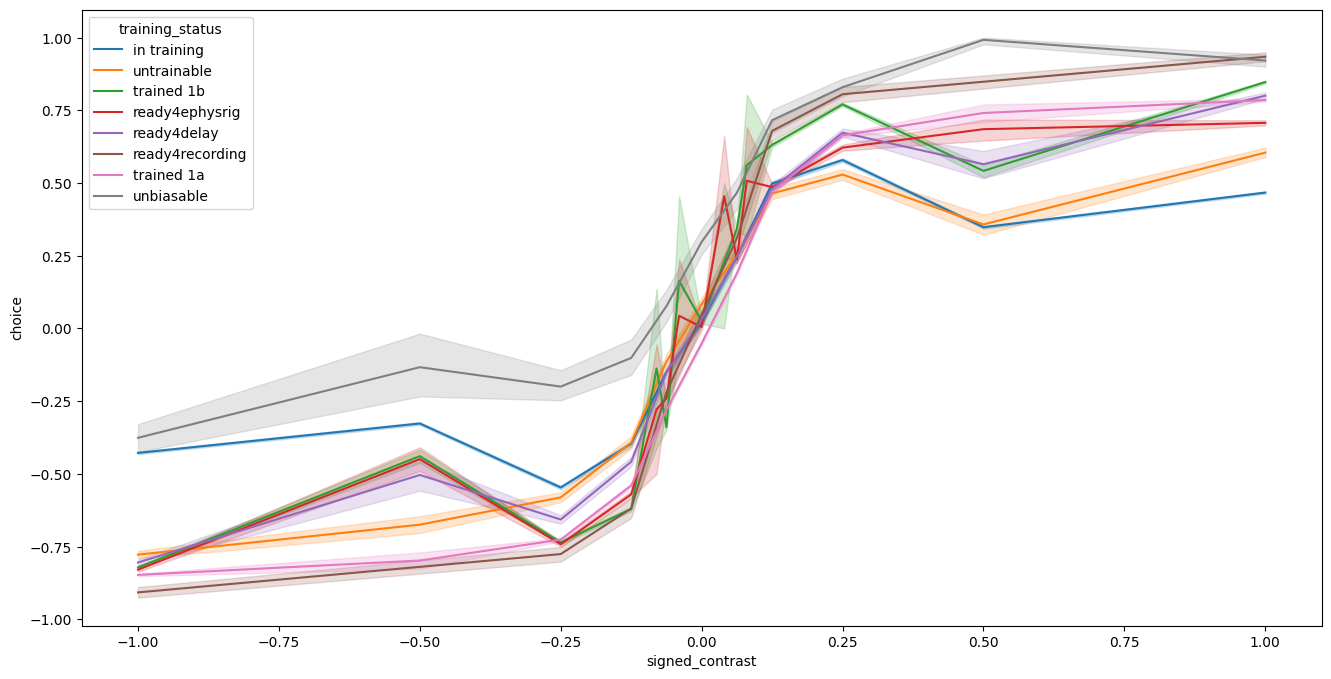

In [14]:
import seaborn as sns
# plot psychometric curves for the whole dataframe
all_trials = all_trials.reset_index()
all_trials['signed_contrast'] = np.nan
i = np.isnan(all_trials['contrastRight'])
all_trials.loc[i , 'signed_contrast'] = all_trials.loc[i, 'contrastLeft']
all_trials.loc[~i, 'signed_contrast'] = - all_trials.loc[~i, 'contrastRight']

fig, ax = plt.subplots(1, 1, sharex=True, figsize=(16, 8))
sns.lineplot(data=all_trials.loc[all_trials['probabilityLeft'] == 0.5], x='signed_contrast', y='choice', hue='training_status', ax=ax)

Or we can look how the performance on easy trial progresses over training days across labs

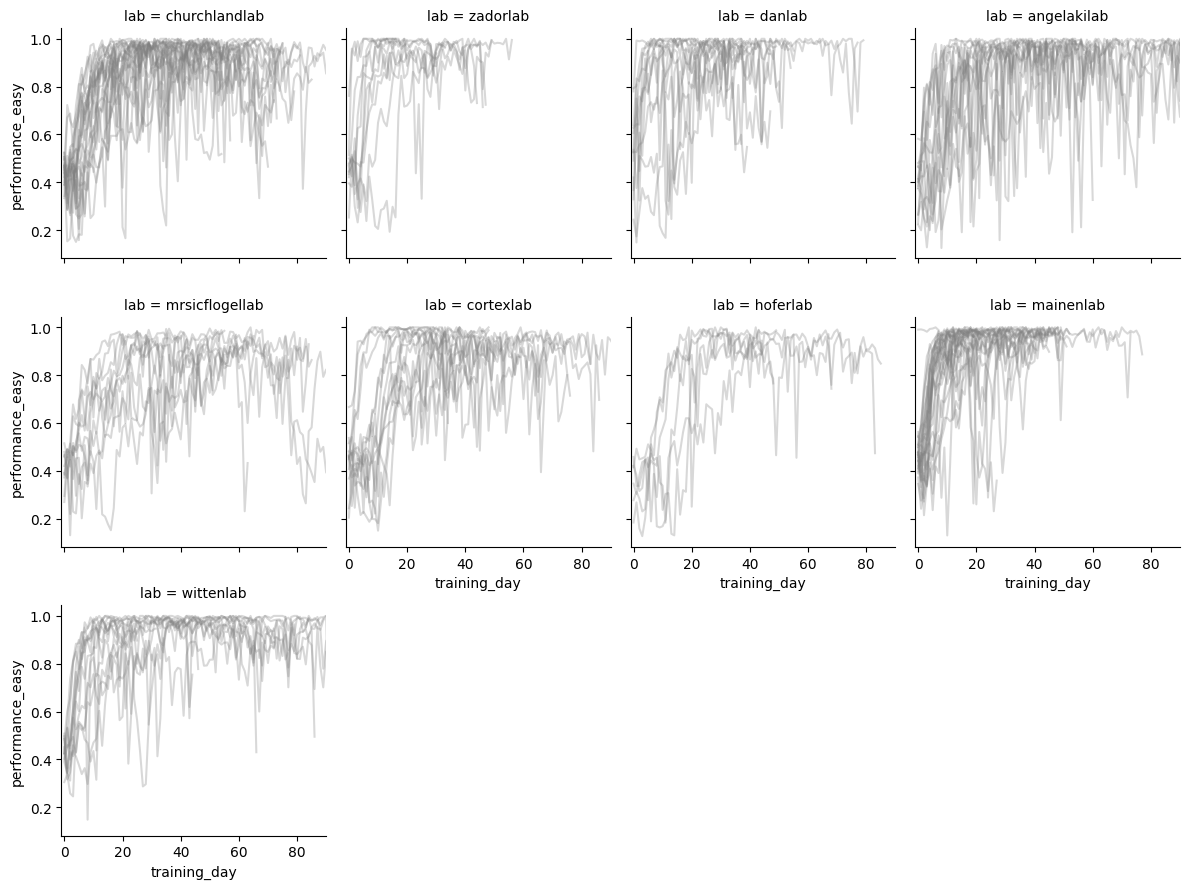

In [15]:
# Remove duplicate rows that we don't need for the plots
fig = sns.FacetGrid(all_trials.drop_duplicates('session'),
                    col="lab", col_wrap=4,
                    sharex=True, sharey=True, aspect=1, hue="subject", xlim=[-1, 90])
fig.map(sns.lineplot, "training_day",
        "performance_easy", color='gray', alpha=0.3)

# Additional resources

Documentation

- [ONE documentation](https://int-brain-lab.github.io/iblenv/notebooks_external/one_quickstart.html#)
- [Getting started with ONE](https://colab.research.google.com/drive/1y3sRI1wC7qbWqN6skvulzPOp6xw8tLm7)
- [Loading trials data](https://int-brain-lab.github.io/iblenv/notebooks_external/loading_trials_data.html)


Where can I find help?
- Issues with the data? Post an issue here: https://neurostars.org/ with the tag `ibl`
- Alternatively post an issue here: https://github.com/int-brain-lab/iblenv/issues
- General questions about the datasets or publications? Email: info@internationalbrainlab.org




> *All data are made available under the CC BY 4.0 license.*

In [16]:
# mouse eventually reached a successful/trainable stage

trainable_statuses = [
    "trained 1a",
    "trained 1b",
    "ready4ephysrig",
    "ready4delay",
    "ready4recording"
]

In [17]:
trainable_subjects = all_trials.loc[
    all_trials["training_status"].isin(trainable_statuses),
    "subject"
].unique()

trained_trials = all_trials[
    all_trials["subject"].isin(trainable_subjects)
].copy()

In [18]:
if "session" not in trained_trials.columns:
    trained_trials = trained_trials.reset_index()

trained_trials = (
    trained_trials
    .sort_values(["subject", "session_start_time", "intervals_0"])
    .reset_index(drop=True)
)

session_order = (
    trained_trials[
        ["subject", "session", "session_start_time"]
    ]
    .drop_duplicates()
    .sort_values(["subject", "session_start_time"])
)

session_order["training_session"] = (
    session_order
    .groupby("subject")
    .cumcount()
)

trained_trials = trained_trials.merge(
    session_order[
        ["subject", "session", "training_session"]
    ],
    on=["subject", "session"],
    how="left"
)

In [19]:
import inspect
from brainbox.behavior.training import compute_reaction_time

In [20]:
session_rows = []

for (subject, session), trials in trained_trials.groupby(["subject", "session"]):

    trials = trials.sort_values("intervals_0").copy()

    try:
        rt = compute_reaction_time(trials)
        median_rt = np.nanmedian(rt)
    except Exception:
        median_rt = np.nan

    correct_trials = trials[trials["feedbackType"] == 1]

    try:
        rt_correct = compute_reaction_time(correct_trials)
        median_rt_correct = np.nanmedian(rt_correct)
    except Exception:
        median_rt_correct = np.nan

    session_rows.append({
        "subject": subject,
        "session": session,
        "training_session": trials["training_session"].iloc[0],
        "session_start_time": trials["session_start_time"].iloc[0],
        "lab": trials["lab"].iloc[0],
        "task_protocol": trials["task_protocol"].iloc[0],
        "training_status": trials["training_status"].iloc[0],

        "n_trials": len(trials),

        "mean_reward": trials["rewardVolume"].mean(),
        "total_reward": trials["rewardVolume"].sum(),
        "reward_fraction": (trials["rewardVolume"] > 0).mean(),
        "mean_reward_when_rewarded": trials.loc[
            trials["rewardVolume"] > 0, "rewardVolume"
        ].mean(),

        "accuracy": (trials["feedbackType"] == 1).mean(),
        "performance_easy": trials["performance_easy"].iloc[0],

        "median_rt": median_rt,
        "median_rt_correct": median_rt_correct
    })

session_df = pd.DataFrame(session_rows)

/usr/local/lib/python3.12/dist-packages/brainbox/behavior/training.py:827: RuntimeWarning: All-NaN slice encountered
  lambda x: np.nanmedian((trials[stim_off_type] - trials[stim_on_type])[(x == signed_contrast) & block_idx]), otypes=[float]


In [21]:
# Each row is the one mouse * one session
session_df

,subject,session,training_session,session_start_time,lab,task_protocol,training_status,n_trials,mean_reward,total_reward,reward_fraction,mean_reward_when_rewarded,accuracy,performance_easy,median_rt,median_rt_correct
0,CSHL045,01019b06-3db6-40aa-820b-4f7d501bb21c,25,2019-12-12 09:28:31.922492,churchlandlab,_iblrig_tasks_trainingChoiceWorld6.2.5,in training,691,1.801737,1245.0,0.720695,2.5,0.720695,0.965909,1.133200,0.981400
1,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,71,2020-02-24 14:41:02.000000,churchlandlab,_iblrig_tasks_ephysChoiceWorld6.2.5,ready4recording,589,1.245331,733.5,0.830221,1.5,0.830221,0.970803,0.467979,0.457944
2,CSHL045,047b4a9b-1a61-41a6-b868-1ce0fccc77c7,44,2020-01-15 09:52:56.738572,churchlandlab,_iblrig_tasks_trainingChoiceWorld6.3.1,untrainable,1124,1.186388,1333.5,0.790925,1.5,0.790925,0.974790,0.422400,0.449700
3,CSHL045,18271dbc-31a2-4ab3-8502-e35559f3f589,38,2020-01-07 09:39:45.947805,churchlandlab,_iblrig_tasks_trainingChoiceWorld6.3.1,in training,836,1.371531,1146.6,0.761962,1.8,0.761962,0.973684,0.928700,0.793000
4,CSHL045,19d56196-94b7-4a8f-93b0-6fb3ffd784cf,23,2019-12-10 09:30:00.816919,churchlandlab,_iblrig_tasks_trainingChoiceWorld6.2.4,in training,537,1.507635,809.6,0.655493,2.3,0.655493,0.913669,1.445500,1.618100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8130,ibl_witten_20,fa27efa4-dd34-4a0f-add7-fa968dd5045a,43,2020-07-23 15:17:25.867065,wittenlab,_iblrig_tasks_trainingChoiceWorld6.4.0,trained 1a,928,0.822737,763.5,0.548491,1.5,0.548491,0.572016,0.890600,3.930500
8131,ibl_witten_20,fdf31a95-2004-4145-b6d2-96125d0a5b6b,13,2020-03-10 10:30:55.464145,wittenlab,_iblrig_tasks_trainingChoiceWorld6.4.0,in training,220,1.920000,422.4,0.800000,2.4,0.800000,0.800000,28.790175,24.655100
8132,ibl_witten_20,fe37cd64-c9bf-45fd-9620-cea26d66dffc,26,2020-06-29 09:03:54.473267,wittenlab,_iblrig_tasks_trainingChoiceWorld6.4.0,trained 1a,1166,1.728130,2015.0,0.691252,2.5,0.691252,0.802974,0.270850,0.317000
8133,ibl_witten_20,fe5457af-9ff8-4f14-8deb-f9b00182c89b,45,2020-07-27 16:31:26.376404,wittenlab,_iblrig_tasks_trainingChoiceWorld6.4.0,trained 1a,1163,1.243336,1446.0,0.828891,1.5,0.828891,1.000000,106.000000,59.000000


In [22]:
# How many unique mice per status
session_df.groupby("training_status")["subject"].nunique()

,subject
training_status,
in training,139
ready4delay,82
ready4ephysrig,114
ready4recording,26
trained 1a,114
trained 1b,133
unbiasable,6
untrainable,12


In [23]:
# `trainable_subjects` was already defined from `all_trials`
training_mice_session_df = session_df.loc[
    session_df["subject"].isin(trainable_subjects)
].copy()

print(
    "Number of trainable mice:",
    training_mice_session_df["subject"].nunique()
)
print(
    "Number of sessions from trainable mice:",
    len(training_mice_session_df)
)

Number of trainable mice: 140
Number of sessions from trainable mice: 8135


In [24]:
#clean table

training_mice_session_df = training_mice_session_df.sort_values(
    ["subject", "training_session"]
).reset_index(drop=True)

training_mice_session_df[
    ["subject", "training_session", "session_start_time",
     "training_status", "mean_reward", "mean_reward_when_rewarded","performance_easy","accuracy",
     "median_rt","median_rt_correct"]
].head(80)

,subject,training_session,session_start_time,training_status,mean_reward,mean_reward_when_rewarded,performance_easy,accuracy,median_rt,median_rt_correct
0,CSHL045,0,2019-11-04 09:29:50.380830,in training,1.574468,3.0,0.524823,0.524823,28.522650,16.022650
1,CSHL045,1,2019-11-05 09:22:24.375415,in training,1.271375,3.0,0.423792,0.423792,29.240500,14.188500
2,CSHL045,2,2019-11-06 09:16:47.976522,in training,1.361905,3.0,0.453968,0.453968,28.297275,19.717450
3,CSHL045,3,2019-11-08 11:04:12.389785,in training,1.091644,3.0,0.363881,0.363881,25.032325,14.917200
4,CSHL045,4,2019-11-11 09:07:10.930437,in training,1.229299,3.0,0.409766,0.409766,26.519400,22.841175
...,...,...,...,...,...,...,...,...,...,...
75,CSHL045,75,2020-02-28 10:07:18.000000,ready4recording,1.254171,1.5,0.981818,0.836114,0.727381,0.759452
76,CSHL046,0,2019-11-04 09:33:24.241616,in training,1.487465,3.0,0.495822,0.495822,28.072050,21.854550
77,CSHL046,1,2019-11-05 09:25:23.032168,in training,0.857143,3.0,0.285714,0.285714,19.213800,9.912650
78,CSHL046,2,2019-11-06 09:18:56.086516,in training,1.166667,3.0,0.388889,0.388889,26.836150,16.263550


In [25]:
#last session status when each mice end

final_status = (
    session_df.sort_values(["subject", "training_session"])
    .groupby("subject")
    .tail(1)
    [[
        "subject",
        "training_session",
        "session_start_time",
        "training_status",
        "mean_reward",
        "mean_reward_when_rewarded",
        "performance_easy",
        "accuracy",
        "median_rt",
        "median_rt_correct"
    ]]
)

final_status["training_status"].value_counts()

,count
training_status,
ready4delay,56
ready4ephysrig,37
ready4recording,26
trained 1b,13
trained 1a,7
unbiasable,1


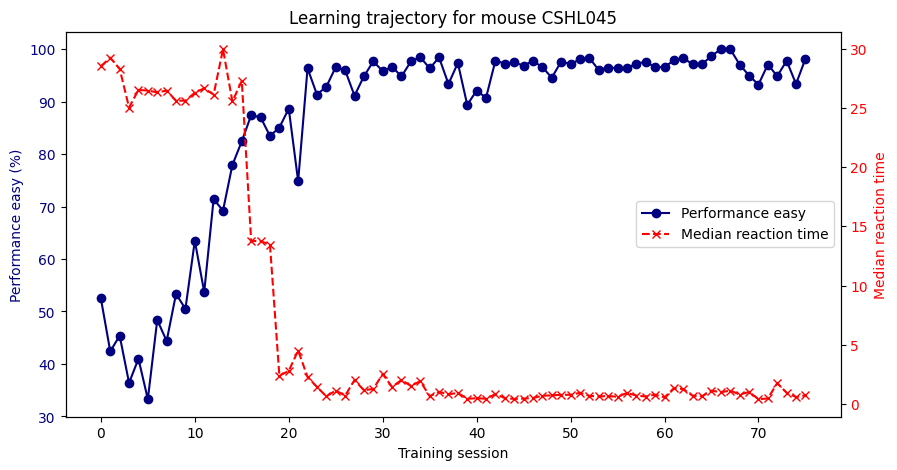

In [26]:
# one mouse learning trajectory across training sessions

import matplotlib.pyplot as plt

mouse = "CSHL045"

df_mouse = training_mice_session_df[
    training_mice_session_df["subject"] == mouse
].sort_values("training_session")

fig, ax1 = plt.subplots(figsize=(10, 5))

# Performance easy: left y-axis
ax1.plot(
    df_mouse["training_session"],
    df_mouse["performance_easy"] * 100,
    marker="o",
    color="navy",
    label="Performance easy"
)

ax1.set_xlabel("Training session")
ax1.set_ylabel("Performance easy (%)", color="navy")
ax1.tick_params(axis="y", labelcolor="navy")

# Median reaction time: right y-axis
ax2 = ax1.twinx()

ax2.plot(
    df_mouse["training_session"],
    df_mouse["median_rt"],
    marker="x",
    linestyle="--",
    color="red",
    label="Median reaction time"
)

ax2.set_ylabel("Median reaction time", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title(f"Learning trajectory for mouse {mouse}")

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right")

plt.show()

In [27]:
# Session-level data used by the population trajectory plots
trajectory_data = (
    training_mice_session_df
    .sort_values(["subject", "training_session"])
    .copy()
)

# Keep the notebook's existing RT range for all four panels.
trajectory_data = trajectory_data.loc[
    (trajectory_data["median_rt"] > 0)
    & (trajectory_data["median_rt"] < 10)
].copy()

trajectory_summary = (
    trajectory_data
    .groupby("training_session")
    .agg(
        mean_perf=("performance_easy", "mean"),
        sem_perf=(
            "performance_easy",
            lambda values:
                values.std()
                / np.sqrt(values.notna().sum())
        ),
        mean_rt=("median_rt", "mean"),
        sem_rt=(
            "median_rt",
            lambda values:
                values.std()
                / np.sqrt(values.notna().sum())
        ),
        n_mice=("subject", "nunique"),
        mean_reward=("mean_reward", "mean"),
        mean_reward_when_rewarded=(
            "mean_reward_when_rewarded",
            "mean"
        )
    )
    .reset_index()
)

min_mice = 4
trajectory_summary_plot = trajectory_summary.loc[
    trajectory_summary["n_mice"] >= min_mice
].copy()

In [50]:
plt.figure(figsize=(7, 4))

plt.plot(
    tracjectory_summary["training_session"],
    tracjectory_summary["n_mice"],
    marker="o"
)

plt.axhline(min_mice, linestyle="--", label=f"min_mice = {min_mice}")

plt.xlabel("Training session")
plt.ylabel("Number of mice contributing")
plt.title("Number of mice contributing to each training session")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'tracjectory_summary' is not defined

<Figure size 700x400 with 0 Axes>

NameError: name 'df' is not defined

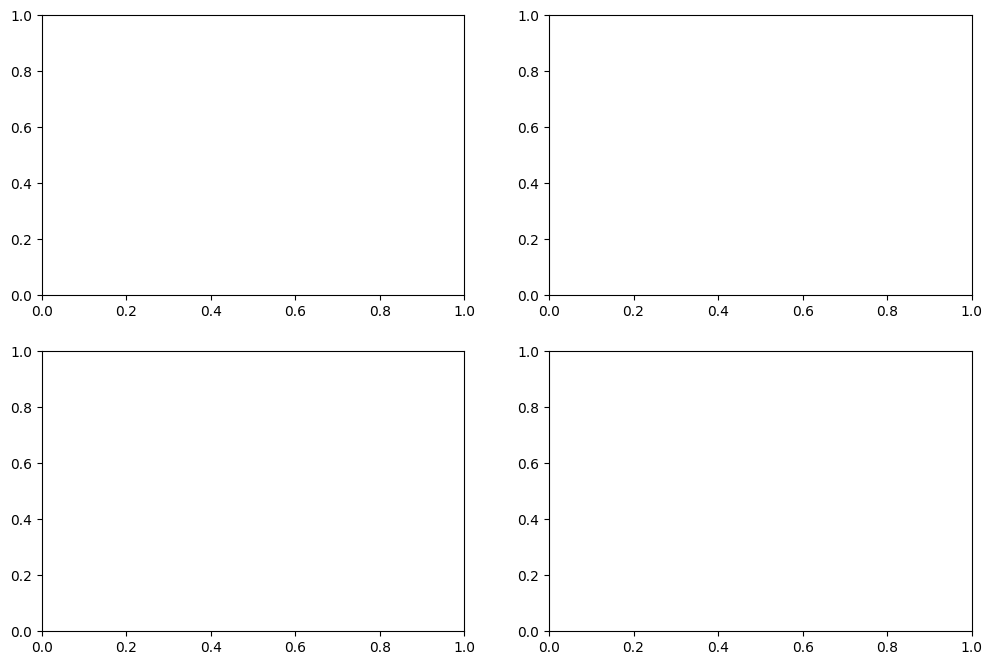

In [30]:
fig, axes = plt.subplots(2,2 , figsize=(12, 8))

# Panel 1: performance trajectories
for mouse, df_mouse in df.groupby("subject"):
    axes[0,0].plot(
        df_mouse["training_session"],
        df_mouse["performance_easy"] * 100,
        color="gray",
        alpha=0.15,
        linewidth=0.8
    )

axes[0,0].plot(
    summary_plot["training_session"],
    summary_plot["mean_perf"] * 100,
    color="blue",
    linewidth=3,
    label="Population mean"
)

axes[0,0].set_xlabel("Training session")
axes[0,0].set_ylabel("Performance easy (%)")
axes[0,0].set_title("Performance trajectories across mice")
axes[0,0].set_ylim(0, 105)
axes[0,0].legend()


# Panel 2: median RT trajectories
for mouse, df_mouse in df.groupby("subject"):
    axes[0,1].plot(
        df_mouse["training_session"],
        df_mouse["median_rt"],
        color="gray",
        alpha=0.15,
        linewidth=0.8
    )

axes[0,1].plot(
    summary_plot["training_session"],
    summary_plot["mean_rt"],
    color="red",
    linewidth=3,
    label="Population mean"
)

axes[0,1].set_xlabel("Training session")
axes[0,1].set_ylabel("Median reaction time")
axes[0,1].set_title("Reaction-time trajectories across mice")
axes[0,1].legend()


# Panel 3: mean reward across all trials
for mouse, df_mouse in df.groupby("subject"):
    axes[1,0].plot(
        df_mouse["training_session"],
        df_mouse["mean_reward"],
        color="gray",
        alpha=0.15,
        linewidth=0.8
    )

axes[1,0].plot(
    summary_plot["training_session"],
    summary_plot["mean_reward"],
    color="green",
    linewidth=3,
    label="Population mean"
)

axes[1,0].set_xlabel("Training session")
axes[1,0].set_ylabel("Mean reward volume per trial")
axes[1,0].set_title("Mean reward across all trials")
axes[1,0].legend()


# Panel 4: mean reward when rewarded only
for mouse, df_mouse in df.groupby("subject"):
    axes[1,1].plot(
        df_mouse["training_session"],
        df_mouse["mean_reward_when_rewarded"],
        color="gray",
        alpha=0.15,
        linewidth=0.8
    )

axes[1,1].plot(
    summary_plot["training_session"],
    summary_plot["mean_reward_when_rewarded"],
    color="purple",
    linewidth=3,
    label="Population mean"
)

axes[1,1].set_xlabel("Training session")
axes[1,1].set_ylabel("Mean reward volume when rewarded")
axes[1,1].set_title("Reward size across session")
axes[1,1].legend()

plt.tight_layout()
plt.show()

In [31]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Performance learning model:
# Performance starts lower and rises toward an asymptote.
def exponential_rise(s, P_0, P_inf, k):
    """
    s: training session
    P_0: initial performance
    P_inf: final/asymptotic performance
    k: learning-rate steepness
       larger k = faster performance improvement
    """
    return P_inf - (P_inf - P_0) * np.exp(-k * s)


# Reaction-time learning model:
# RT starts high and decreases toward an asymptote.
def exponential_decay(s, RT_0, RT_inf, k):
    """
    s: training session
    RT_0: initial reaction time
    RT_inf: final/asymptotic reaction time
    k: speed-improvement steepness
       larger k = faster RT decrease
    """
    return (RT_0 - RT_inf) * np.exp(-k * s) + RT_inf


In [32]:
# Primary learning rate measue by performance easy definition

def fit_performance_learning_rate(df_mouse_sessions, min_sessions=4):
    """
    Fit learning rate based on performance_easy across training sessions.
    This is the primary learning-rate measure.

    Larger k = faster improvement in easy-trial performance.
    """

    df = df_mouse_sessions.copy()
    df = df.dropna(subset=["training_session", "performance_easy"])
    df = df.sort_values("training_session")

    if len(df) < min_sessions:
        return None, None, None

    x = df["training_session"].values
    y = df["performance_easy"].values

    # Re-center x so the first session is 0
    x_fit = x - x.min()

    # performance_easy should be between 0 and 1
    bounds = ([0.0, 0.0, 0.001], [1.0, 1.0, 2.0])

    initial_guess = [
        np.clip(y[0], bounds[0][0], bounds[1][0]),
        np.clip(y[-1], bounds[0][1], bounds[1][1]),
        0.1
    ]

    try:
        params, _ = curve_fit(
            exponential_rise,
            x_fit,
            y,
            p0=initial_guess,
            bounds=bounds,
            maxfev=10000
        )

        P_0, P_inf, k = params

        x_smooth = np.linspace(x_fit.min(), x_fit.max(), 200)
        y_smooth = exponential_rise(x_smooth, P_0, P_inf, k)

        x_smooth_original = x_smooth + x.min()

        return k, x_smooth_original, y_smooth

    except RuntimeError:
        return None, None, None

In [33]:
# Secondary learning rate measured by median reaction time
def fit_reaction_time_learning_rate(df_mouse_sessions, min_sessions=4):
    """
    Fit reaction-time decrease across training sessions using median_rt.

    median_rt = median reaction time across all trials in a session.
    Larger k = faster decrease in reaction time.
    """

    df = df_mouse_sessions.copy()
    df = df.dropna(subset=["training_session", "median_rt"])
    df = df[df["median_rt"] > 0]
    df = df.sort_values("training_session")

    if len(df) < min_sessions:
        return None, None, None

    x = df["training_session"].values
    y = df["median_rt"].values

    # Re-center x so the first session is 0
    x_fit = x - x.min()

    bounds = ([0.05, 0.05, 0.001], [10.0, 5.0, 2.0])

    initial_guess = [
        np.clip(y[0], bounds[0][0], bounds[1][0]),
        np.clip(y[-1], bounds[0][1], bounds[1][1]),
        0.1
    ]

    try:
        params, _ = curve_fit(
            exponential_decay,
            x_fit,
            y,
            p0=initial_guess,
            bounds=bounds,
            maxfev=10000
        )

        RT_0, RT_inf, k = params

        x_smooth = np.linspace(x_fit.min(), x_fit.max(), 200)
        y_smooth = exponential_decay(x_smooth, RT_0, RT_inf, k)

        x_smooth_original = x_smooth + x.min()

        return k, x_smooth_original, y_smooth

    except RuntimeError:
        return None, None, None

In [34]:
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown, fixed

def plot_mouse_reward_learning_both(mouse, session_table=training_mice_session_df):
    """
    Interactive demo for one mouse:
    1. performance_easy across training sessions
    2. median_rt across training sessions
    3. reward variables across training sessions
    """

    df_mouse = (
        session_table[session_table["subject"] == mouse]
        .sort_values("training_session")
        .copy()
    )

    if len(df_mouse) == 0:
        print(f"No data found for mouse {mouse}")
        return

    # Primary learning measure: performance_easy
    performance_k, performance_x_fit, performance_y_fit = (
        fit_performance_learning_rate(df_mouse)
    )

    # Secondary speed measure: median_rt
    reaction_time_k, reaction_time_x_fit, reaction_time_y_fit = (
        fit_reaction_time_learning_rate(df_mouse)
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # =========================
    # Panel 1: performance learning
    # =========================
    axes[0].plot(
        df_mouse["training_session"],
        df_mouse["performance_easy"] * 100,
        marker="o",
        color="blue",
        label="Performance easy"
    )

    if performance_k is not None:
        axes[0].plot(
            performance_x_fit,
            performance_y_fit * 100,
            color="black",
            linewidth=2.5,
            label=f"Fit: k={performance_k:.3f}"
        )
        performance_title = f"Performance learning\nk={performance_k:.3f}"
    else:
        performance_title = "Performance learning\nfit failed"

    axes[0].set_xlabel("Training session")
    axes[0].set_ylabel("Performance easy (%)")
    axes[0].set_title(performance_title)
    axes[0].set_ylim(0, 105)
    axes[0].legend()

    # =========================
    # Panel 2: reaction-time decrease
    # =========================
    axes[1].plot(
        df_mouse["training_session"],
        df_mouse["median_rt"],
        marker="x",
        linestyle="--",
        color="red",
        label="Median reaction time"
    )

    if reaction_time_k is not None:
        axes[1].plot(
            reaction_time_x_fit,
            reaction_time_y_fit,
            color="black",
            linewidth=2.5,
            label=f"Fit: k={reaction_time_k:.3f}"
        )
        reaction_time_title = f"Reaction-time decrease\nk={reaction_time_k:.3f}"
    else:
        reaction_time_title = "Reaction-time decrease\nfit failed"

    axes[1].set_xlabel("Training session")
    axes[1].set_ylabel("Median reaction time")
    axes[1].set_title(reaction_time_title)
    axes[1].legend()

    # =========================
    # Panel 3: reward variables
    # =========================
    axes[2].plot(
        df_mouse["training_session"],
        df_mouse["mean_reward"],
        marker="o",
        color="green",
        label="Mean reward across all trials"
    )

    axes[2].plot(
        df_mouse["training_session"],
        df_mouse["mean_reward_when_rewarded"],
        marker="s",
        linestyle="--",
        color="purple",
        label="Mean reward when rewarded"
    )

    axes[2].set_xlabel("Training session")
    axes[2].set_ylabel("Reward volume")
    axes[2].set_title("Reward variables")
    axes[2].legend()

    fig.suptitle(f"Learning and reward trajectory for mouse {mouse}", fontsize=14)
    plt.tight_layout()
    plt.show()

In [35]:
#Single mice example

mouse_dropdown = Dropdown(
    options=sorted(training_mice_session_df["subject"].unique()),
    description="Mouse:"
)

interact(
    plot_mouse_reward_learning_both,
    mouse=mouse_dropdown,
    session_table=fixed(training_mice_session_df)
);

interactive(children=(Dropdown(description='Mouse:', options=('CSHL045', 'CSHL046', 'CSHL047', 'CSHL049', 'CSH…

**Panel 1: Performance learning**

x = training_session; y = performance_easy;

fit = exponential rise

=>primary learning measure

**Panel 2: Reaction-time change**

x = training_session; y = median_rt;

fit = exponential decay

=>secondary speed / reaction-time measure

**Panel 3: Reward variables**

x = training_session; y1 = mean_reward; y2 = mean_reward_when_rewarded

=>reward exposure vs reward size

The performance easy is used as primry learning rate measure, the reaction time was treated as a secondary behavioral measure

# **Next, look at only early in-training session, what are the effects of reward volume to learning rate (performance easy and reaction time?)**

In [36]:
early_training_sessions = (
    training_mice_session_df[
        training_mice_session_df["training_status"] == "in training"
    ]
    .sort_values(["subject", "training_session"])
    .copy()
)

# Keep only first 10 in-training sessions per mouse
early_training_sessions["early_session_number"] = (
    early_training_sessions
    .groupby("subject")
    .cumcount()
)

early_training_sessions = early_training_sessions[
    early_training_sessions["early_session_number"] < 10
].copy()

early_training_sessions[
    [
        "subject",
        "training_session",
        "early_session_number",
        "training_status",
        "mean_reward",
        "mean_reward_when_rewarded",
        "performance_easy",
        "median_rt"
    ]
].head(20)

,subject,training_session,early_session_number,training_status,mean_reward,mean_reward_when_rewarded,performance_easy,median_rt
0,CSHL045,0,0,in training,1.574468,3.0,0.524823,28.522650
1,CSHL045,1,1,in training,1.271375,3.0,0.423792,29.240500
2,CSHL045,2,2,in training,1.361905,3.0,0.453968,28.297275
3,CSHL045,3,3,in training,1.091644,3.0,0.363881,25.032325
4,CSHL045,4,4,in training,1.229299,3.0,0.409766,26.519400
5,CSHL045,5,5,in training,0.998230,3.0,0.332743,26.465100
6,CSHL045,6,6,in training,1.451777,3.0,0.483926,26.316350
7,CSHL045,7,7,in training,1.331023,3.0,0.443674,26.459375
8,CSHL045,8,8,in training,1.600506,3.0,0.533502,25.614850
9,CSHL045,9,9,in training,1.464548,2.9,0.505017,25.609600


In [37]:
#early_mean_reward = mean reward across first 10 in-training sessions
#early_reward_size = mean reward when rewarded across first 10 in-training sessions
#performance_slope = how quickly performance_easy increases across those sessions
#reaction_time_slope = how reaction time changes across those sessions


early_mouse_results = []

for mouse, mouse_data in early_training_sessions.groupby("subject"):
    mouse_data = (
        mouse_data
        .sort_values("early_session_number")
        .copy()
    )

    if len(mouse_data) < 8:
        continue

    first_sessions = mouse_data.loc[
        mouse_data["early_session_number"].isin([0, 1, 2])
    ]
    late_sessions = mouse_data.loc[
        mouse_data["early_session_number"].isin([7, 8, 9])
    ]

    if len(first_sessions) < 2 or len(late_sessions) < 2:
        continue

    early_performance = first_sessions["performance_easy"].mean()
    later_performance = late_sessions["performance_easy"].mean()
    early_rt = first_sessions["median_rt"].mean()
    later_rt = late_sessions["median_rt"].mean()

    early_mouse_results.append({
        "subject": mouse,
        "lab": mouse_data["lab"].iloc[0],
        "n_early_sessions": len(mouse_data),

        "early_mean_reward": mouse_data["mean_reward"].mean(),
        "early_mean_reward_when_rewarded": (
            mouse_data["mean_reward_when_rewarded"].mean()
        ),
        "early_reward_fraction": (
            mouse_data["reward_fraction"].mean()
        ),

        "early_performance_start": early_performance,
        "early_performance_late": later_performance,
        "early_performance_improvement": (
            later_performance - early_performance
        ),

        "early_rt_start": early_rt,
        "early_rt_late": later_rt,
        "early_rt_decrease": early_rt - later_rt,
        "early_log_rt_decrease": (
            np.log(early_rt) - np.log(later_rt)
            if early_rt > 0 and later_rt > 0
            else np.nan
        )
    })

early_mouse_results_df = pd.DataFrame(
    early_mouse_results
)

display(early_mouse_results_df.head(20))

,subject,lab,n_early_sessions,early_mean_reward,early_mean_reward_when_rewarded,early_reward_fraction,early_performance_start,early_performance_late,early_performance_improvement,early_rt_start,early_rt_late,early_rt_decrease,early_log_rt_decrease
0,CSHL045,churchlandlab,10,1.337478,2.990000,0.447509,0.467528,0.494064,0.026537,28.686808,25.894608,2.792200,0.102403
1,CSHL046,churchlandlab,10,1.286361,2.990000,0.431116,0.390142,0.618183,0.228042,24.707333,26.709800,-2.002467,-0.077930
2,CSHL047,churchlandlab,10,1.449814,2.830000,0.519491,0.361908,0.660039,0.298131,23.454733,27.309317,-3.854583,-0.152156
3,CSHL049,churchlandlab,10,1.166868,2.970000,0.396776,0.436130,0.654539,0.218409,23.367417,21.494117,1.873300,0.083563
4,CSHL051,churchlandlab,10,1.632556,2.820000,0.585975,0.409472,0.758408,0.348936,23.022858,13.214950,9.807908,0.555139
5,CSHL052,churchlandlab,10,1.159830,2.950000,0.392594,0.435208,0.406395,-0.028813,25.821075,25.101808,0.719267,0.028251
6,CSHL053,churchlandlab,10,1.054670,2.990000,0.352893,0.251129,0.460192,0.209063,19.984025,22.605050,-2.621025,-0.123240
7,CSHL054,churchlandlab,10,1.727009,2.810000,0.618325,0.465841,0.721082,0.255241,26.492750,18.190525,8.302225,0.375970
8,CSHL055,churchlandlab,10,1.295270,2.780000,0.465993,0.460108,0.488721,0.028613,27.811833,25.294925,2.516908,0.094858
9,CSHL058,churchlandlab,10,1.777005,2.840000,0.632144,0.461956,0.769698,0.307742,26.925217,18.566958,8.358258,0.371680


In [38]:
def plot_linear_association(
    data,
    x_column,
    y_column,
    x_label,
    y_label,
    title,
    fit_decimals=2,
    x_limits=None,
    y_limits=None
):
    plot_data = data.dropna(
        subset=[x_column, y_column]
    ).copy()

    x = plot_data[x_column].to_numpy()
    y = plot_data[y_column].to_numpy()

    pearson_result = pearsonr(x, y)
    spearman_result = spearmanr(x, y)

    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept

    plt.figure(figsize=(6, 5))
    axis = plt.gca()

    axis.scatter(x, y, alpha=0.7)
    axis.axhline(0, linestyle='--', linewidth=1)
    axis.plot(
        x_line,
        y_line,
        color='black',
        linewidth=2,
        label=(
            f'fit: y = {slope:.{fit_decimals}f}x '
            f'{intercept:+.{fit_decimals}f}'
        )
    )

    if x_limits is not None:
        axis.set_xlim(*x_limits)
    if y_limits is not None:
        axis.set_ylim(*y_limits)

    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.set_title(
        f'{title}\n'
        f'Pearson r={pearson_result.statistic:.3f}, '
        f'p={pearson_result.pvalue:.2e}; '
        f'Spearman r={spearman_result.statistic:.3f}, '
        f'p={spearman_result.pvalue:.2e}'
    )
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.legend(frameon=False)

    plt.tight_layout()
    plt.show()

In [39]:
plot_linear_association(
    early_mouse_results_df,
    x_column="early_mean_reward",
    y_column="early_performance_improvement",
    x_label="Early mean reward across first 10 in-training sessions",
    y_label="Early performance improvement",
    title="Early reward exposure vs early performance improvement",
    fit_decimals=1,
    x_limits=(0.75, 2.25),
    y_limits=(-0.5, 1)
)

NameError: name 'pearsonr' is not defined

In [40]:
reward_size_data = early_mouse_results_df.dropna(
    subset=["early_mean_reward_when_rewarded"]
)

plot_linear_association(
    early_mouse_results_df,
    x_column="early_mean_reward_when_rewarded",
    y_column="early_performance_improvement",
    x_label="Early mean reward when rewarded across first 10 in-training sessions",
    y_label="Early performance improvement",
    title="Early reward size vs early performance improvement",
    fit_decimals=2,
    x_limits=(
        reward_size_data["early_mean_reward_when_rewarded"].min() - 0.1,
        reward_size_data["early_mean_reward_when_rewarded"].max() + 0.1
    ),
    y_limits=(-0.5, 1)
)

NameError: name 'pearsonr' is not defined

In [41]:
#?some mice are not really reacting, should set a reaction time range?

In [42]:
plot_linear_association(
    early_mouse_results_df,
    x_column="early_reward_fraction",
    y_column="early_performance_improvement",
    x_label="Fraction of rewarded trials during first 10 in-training sessions",
    y_label="Early performance improvement",
    title="Early reward frequency vs early performance improvement"
)

NameError: name 'pearsonr' is not defined

In [43]:
plot_linear_association(
    early_mouse_results_df,
    x_column="early_mean_reward",
    y_column="early_rt_decrease",
    x_label="Early mean reward across first 10 in-training sessions",
    y_label="Early reaction-time decrease",
    title="Early reward exposure vs early reaction-time decrease",
    fit_decimals=1
)

NameError: name 'pearsonr' is not defined

In [44]:
plot_linear_association(
    early_mouse_results_df,
    x_column="early_mean_reward",
    y_column="early_log_rt_decrease",
    x_label="Early mean reward across first 10 in-training sessions",
    y_label="Early log reaction-time decrease",
    title="Early reward exposure vs early log RT decrease",
    fit_decimals=2
)

NameError: name 'pearsonr' is not defined

In [45]:
plot_linear_association(
    learning_reward_model_df,
    x_column="early_mean_reward",
    y_column="full_performance_learning_k",
    x_label="Early mean reward across first 10 in-training sessions",
    y_label="Full performance learning rate k",
    title="Early reward exposure vs full performance learning rate",
    fit_decimals=3
)

NameError: name 'learning_reward_model_df' is not defined

In [46]:
plot_linear_association(
    learning_reward_model_df,
    x_column="early_mean_reward_when_rewarded",
    y_column="full_performance_learning_k",
    x_label="Early reward size across first 10 in-training sessions",
    y_label="Full performance learning rate k",
    title="Early reward exposure vs full performance learning rate",
    fit_decimals=3
)

NameError: name 'learning_reward_model_df' is not defined

In [51]:
model_data = early_mouse_results_df.dropna(
    subset=[
        "early_performance_improvement",
        "early_mean_reward",
        "early_performance_start",
        "early_rt_start",
        "lab"
    ]
).copy()

model = smf.ols(
    "early_performance_improvement ~ "
    "early_mean_reward + early_performance_start + "
    "early_rt_start + C(lab)",
    data=model_data
).fit()

print(model.summary())

NameError: name 'smf' is not defined

In [52]:
model_data_k = learning_reward_model_df.dropna(
    subset=[
        "full_performance_learning_k",
        "early_mean_reward",
        "early_mean_reward_when_rewarded",
        "early_performance_start",
        "early_rt_start",
        "lab"
    ]
).copy()

model_k = smf.ols(
    "full_performance_learning_k ~ "
    "early_mean_reward + early_performance_start + "
    "early_rt_start + C(lab)",
    data=model_data_k
).fit()

print(model_k.summary())

NameError: name 'learning_reward_model_df' is not defined

In [53]:
learning_reward_model_df = early_mouse_results_df.merge(
    full_learning_results_df,
    on="subject",
    how="inner"
)

print(
    "Number of mice with early reward and full learning k:",
    learning_reward_model_df["subject"].nunique()
)

display(learning_reward_model_df.head())

NameError: name 'full_learning_results_df' is not defined

# Early previous choice effect, choice history section

In [54]:
early_protocol_summary = (
    early_training_sessions
    .groupby("task_protocol")
    .agg(
        n_sessions=("session", "nunique"),
        n_mice=("subject", "nunique")
    )
    .sort_values("n_sessions", ascending=False)
)

display(early_protocol_summary)

,n_sessions,n_mice
task_protocol,,
_iblrig_tasks_trainingChoiceWorld6.1.3,133,18
_iblrig_tasks_trainingChoiceWorld5.2.7,110,21
_iblrig_tasks_trainingChoiceWorld4.1.3,107,13
_iblrig_tasks_trainingChoiceWorld3.7.6,98,23
_iblrig_tasks_trainingChoiceWorld6.3.1,92,13
_iblrig_tasks_trainingChoiceWorld6.2.5,77,8
_iblrig_tasks_trainingChoiceWorld5.3.0,75,13
_iblrig_tasks_trainingChoiceWorld5.2.9,67,18
_iblrig_tasks_trainingChoiceWorld4.0.1,64,12


In [55]:
# Session identifiers for the first 10 "in training" sessions
early_session_keys = (
    early_training_sessions[
        ["subject", "session", "early_session_number"]
    ]
    .drop_duplicates()
)

early_trials = (
    trained_trials
    .merge(
        early_session_keys,
        on=["subject", "session"],
        how="inner"
    )
    .sort_values(["subject", "session", "intervals_0"])
    .copy()
)

print(
    early_trials["probabilityLeft"]
    .value_counts(dropna=False)
    .sort_index()
)

probabilityLeft
0.0     22407
0.1     22825
0.2     24491
0.3     24108
0.4     23759
0.5    421028
0.6     22747
0.7     22750
0.8     22299
0.9     19997
1.0     19518
Name: count, dtype: int64


In [56]:
early_trials = early_trials.copy()

probability_left = early_trials["probabilityLeft"].astype(float)
task_protocol = early_trials["task_protocol"].astype(str)

is_training_protocol = task_protocol.str.contains(
    "trainingChoiceWorld",
    case=False,
    na=False
)

is_biased_protocol = task_protocol.str.contains(
    "biasedChoiceWorld",
    case=False,
    na=False
)

is_probability_05 = np.isclose(
    probability_left, 0.5, atol=1e-6
)
is_probability_02 = np.isclose(
    probability_left, 0.2, atol=1e-6
)
is_probability_08 = np.isclose(
    probability_left, 0.8, atol=1e-6
)

early_trials["trial_context"] = np.select(
    [
        is_training_protocol & is_probability_05,
        is_training_protocol & ~is_probability_05,
        is_biased_protocol & is_probability_05,
        is_biased_protocol & is_probability_08,
        is_biased_protocol & is_probability_02
    ],
    [
        "training: balanced probability",
        "training: adaptive probability",
        "biased task: initial unbiased block",
        "biased task: left-biased block",
        "biased task: right-biased block"
    ],
    default="other or unexpected"
)

print(
    early_trials["trial_context"]
    .value_counts(dropna=False)
)

display(
    pd.crosstab(
        early_trials["task_protocol"],
        early_trials["trial_context"]
    )
)


trial_context
training: balanced probability    421028
training: adaptive probability    224901
Name: count, dtype: int64


trial_context,training: adaptive probability,training: balanced probability
task_protocol,,
_iblrig_tasks_trainingChoiceWorld3.2.3,0,8299
_iblrig_tasks_trainingChoiceWorld3.4.1,0,5278
_iblrig_tasks_trainingChoiceWorld3.5.1,131,147
_iblrig_tasks_trainingChoiceWorld3.5.2,2918,6376
_iblrig_tasks_trainingChoiceWorld3.5.3,7936,17890
_iblrig_tasks_trainingChoiceWorld3.5.4,3976,16515
_iblrig_tasks_trainingChoiceWorld3.6.0,7154,16864
_iblrig_tasks_trainingChoiceWorld3.7.1,399,6047
_iblrig_tasks_trainingChoiceWorld3.7.2,1307,2193


In [57]:

early_trials["absolute_probability_imbalance"] = (
    early_trials["probabilityLeft"] - 0.5
).abs()

early_reward_sensitivity = (
    early_trials
    .groupby("subject")
    .agg(
        early_mean_reward_all_trials=(
            "rewardVolume",
            "mean"
        ),

        early_mean_reward_probability_05=(
            "rewardVolume",
            lambda x: x[
                np.isclose(
                    early_trials.loc[x.index, "probabilityLeft"],
                    0.5,
                    atol=1e-6
                )
            ].mean()
        ),

        early_mean_probability_imbalance=(
            "absolute_probability_imbalance",
            "mean"
        ),

        early_fraction_probability_05=(
            "probabilityLeft",
            lambda x: np.isclose(
                x,
                0.5,
                atol=1e-6
            ).mean()
        ),

        early_n_trials=(
            "rewardVolume",
            "size"
        )
    )
    .reset_index()

)
display(early_reward_sensitivity.head())

,subject,early_mean_reward_all_trials,early_mean_reward_probability_05,early_mean_probability_imbalance,early_fraction_probability_05,early_n_trials
0,CSHL045,1.352133,1.364906,0.149317,0.493789,4830
1,CSHL046,1.260025,1.548903,0.201732,0.447110,4793
2,CSHL047,1.502085,1.689851,0.132621,0.579784,5659
3,CSHL049,1.249473,1.652989,0.226844,0.447326,4936
4,CSHL051,1.682904,1.803985,0.096754,0.671454,5083


In [58]:
early_trials["previous_choice"] = (
    early_trials
    .groupby(["subject", "session"])["choice"]
    .shift(1)
)

early_trials["previous_feedback"] = (
    early_trials
    .groupby(["subject", "session"])["feedbackType"]
    .shift(1)
)

early_trials["previous_probabilityLeft"] = (
    early_trials
    .groupby(["subject", "session"])["probabilityLeft"]
    .shift(1)
)

In [59]:
current_trial_is_unbiased = np.isclose(
    early_trials["probabilityLeft"].astype(float),
    0.5,
    atol=1e-6
)

valid_current_choice = early_trials["choice"].isin([-1, 1])
valid_previous_choice = early_trials["previous_choice"].isin([-1, 1])
valid_previous_feedback = early_trials["previous_feedback"].isin([-1, 1])

early_unbiased_history_trials = early_trials[
    current_trial_is_unbiased
    & valid_current_choice
    & valid_previous_choice
    & valid_previous_feedback
].copy()

print(
    "Number of unbiased history trials:",
    len(early_unbiased_history_trials)
)

print(
    "Number of mice:",
    early_unbiased_history_trials["subject"].nunique()
)

Number of unbiased history trials: 418082
Number of mice: 139


In [60]:

previous_trial_is_unbiased = np.isclose(
    early_trials["previous_probabilityLeft"].astype(float),
    0.5,
    atol=1e-6
)

early_unbiased_pair_trials = early_trials[
    current_trial_is_unbiased
    & previous_trial_is_unbiased
    & valid_current_choice
    & valid_previous_choice
    & valid_previous_feedback
].copy()

In [61]:
history_data = early_unbiased_history_trials.copy()

# Current choice: 1 means right, 0 means left
history_data["current_choice_right"] = (
    history_data["choice"] == -1
).astype(int)

# Previous choice: +1 means right, -1 means left
history_data["previous_choice_signed"] = np.where(
    history_data["previous_choice"] == -1,
    1,
    -1
)

# Previous outcome: +1 rewarded/correct, -1 error
history_data["previous_outcome_signed"] = np.where(
    history_data["previous_feedback"] == 1,
    1,
    -1
)

# Right contrast minus left contrast:
# positive values favour a rightward response
history_data["signed_contrast_right"] = (
    history_data["contrastRight"].fillna(0)
    - history_data["contrastLeft"].fillna(0)
)

# Previous-choice × previous-outcome interaction.
# Its sign determines whether persistence is stronger
# after reward or after error; the name alone does not
# guarantee a classic win-stay/lose-switch effect.
history_data["win_stay_lose_switch"] = (
    history_data["previous_choice_signed"]
    * history_data["previous_outcome_signed"]
)



In [62]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

history_model_compact = smf.glm(
    """
    current_choice_right
    ~ signed_contrast_right
    + previous_choice_signed
    + win_stay_lose_switch
    """,
    data=history_data,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": history_data["subject"]
    }
)

print(history_model_compact.summary())

                  Generalized Linear Model Regression Results                   
Dep. Variable:     current_choice_right   No. Observations:               418082
Model:                              GLM   Df Residuals:                   418078
Model Family:                  Binomial   Df Model:                            3
Link Function:                    Logit   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:            -2.7143e+05
Date:                  Thu, 23 Jul 2026   Deviance:                   5.4286e+05
Time:                          07:52:20   Pearson chi2:                 4.19e+05
No. Iterations:                       5   Pseudo R-squ. (CS):            0.08409
Covariance Type:                cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercep

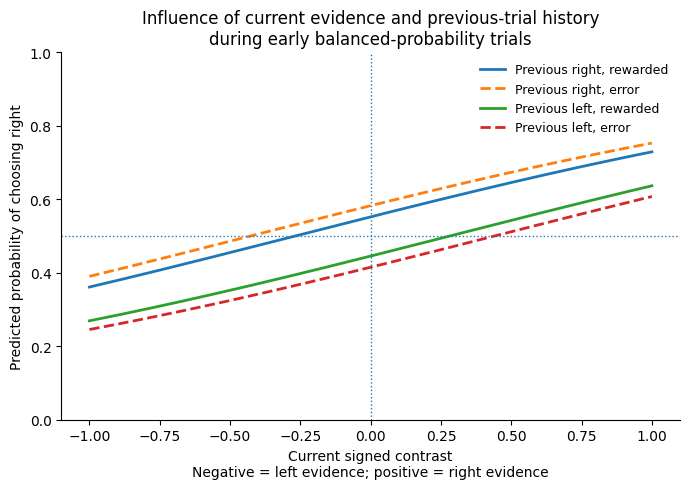

In [63]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

contrast_grid = np.linspace(
    history_data["signed_contrast_right"].min(),
    history_data["signed_contrast_right"].max(),
    200
)

conditions = [
    {
        "label": "Previous right, rewarded",
        "previous_choice_signed": 1,
        "previous_outcome_signed": 1,
        "linestyle": "-"
    },
    {
        "label": "Previous right, error",
        "previous_choice_signed": 1,
        "previous_outcome_signed": -1,
        "linestyle": "--"
    },
    {
        "label": "Previous left, rewarded",
        "previous_choice_signed": -1,
        "previous_outcome_signed": 1,
        "linestyle": "-"
    },
    {
        "label": "Previous left, error",
        "previous_choice_signed": -1,
        "previous_outcome_signed": -1,
        "linestyle": "--"
    }
]

plt.figure(figsize=(7, 5))
ax = plt.gca()

for condition in conditions:

    prediction_data = pd.DataFrame({
        "signed_contrast_right": contrast_grid,
        "previous_choice_signed":
            condition["previous_choice_signed"],
        "win_stay_lose_switch":
            condition["previous_choice_signed"]
            * condition["previous_outcome_signed"]
    })

    predicted_probability = history_model_compact.predict(
        prediction_data
    )

    ax.plot(
        contrast_grid,
        predicted_probability,
        linestyle=condition["linestyle"],
        linewidth=2,
        label=condition["label"]
    )

ax.axhline(
    0.5,
    linestyle=":",
    linewidth=1
)

ax.axvline(
    0,
    linestyle=":",
    linewidth=1
)

ax.set_xlabel(
    "Current signed contrast\n"
    "Negative = left evidence; positive = right evidence"
)

ax.set_ylabel(
    "Predicted probability of choosing right"
)

ax.set_title(
    "Influence of current evidence and previous-trial history\n"
    "during early balanced-probability trials"
)

ax.set_ylim(0, 1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=9
)

plt.tight_layout()
plt.show()

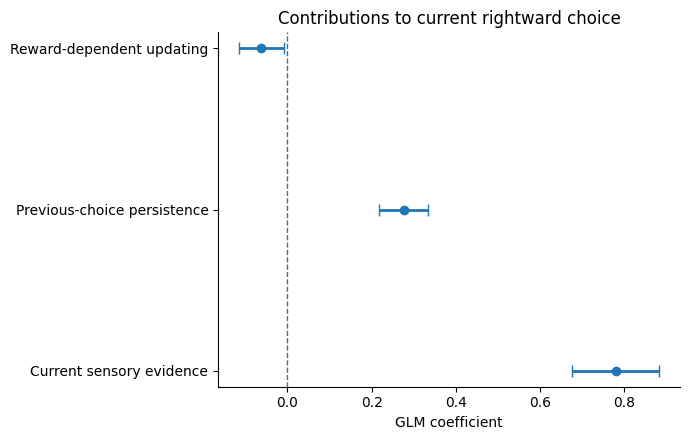

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

terms = [
    "signed_contrast_right",
    "previous_choice_signed",
    "win_stay_lose_switch"
]

coefficient_labels = {
    "signed_contrast_right": "Current sensory evidence",
    "previous_choice_signed": "Previous-choice persistence",
    "win_stay_lose_switch": "Reward-dependent updating"
}

confidence_intervals = history_model_compact.conf_int()

coefficient_data = pd.DataFrame({
    "term": terms,
    "coefficient": history_model_compact.params[terms],
    "lower_ci": confidence_intervals.loc[terms, 0],
    "upper_ci": confidence_intervals.loc[terms, 1]
}).reset_index(drop=True)

coefficient_data["label"] = coefficient_data["term"].map(
    coefficient_labels
)

plt.figure(figsize=(7, 4.5))
ax = plt.gca()

y_positions = np.arange(len(coefficient_data))

lower_error = (
    coefficient_data["coefficient"]
    - coefficient_data["lower_ci"]
)

upper_error = (
    coefficient_data["upper_ci"]
    - coefficient_data["coefficient"]
)

ax.errorbar(
    coefficient_data["coefficient"],
    y_positions,
    xerr=[lower_error, upper_error],
    fmt="o",
    capsize=4,
    linewidth=2
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_yticks(y_positions)
ax.set_yticklabels(coefficient_data["label"])

ax.set_xlabel("GLM coefficient")
ax.set_title(
    "Contributions to current rightward choice"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [65]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

wwsls_data = history_data.copy()

wsls_data["current_choice_signed"] = np.where(
    wsls_data["current_choice_right"] == 1,
    1,
    -1
)

wsls_data["repeated_choice"] = (
    wsls_data["current_choice_signed"]
    == wsls_data["previous_choice_signed"]
)


mouse_results = []

for subject, mouse_data in wsls_data.groupby("subject"):

    rewarded_trials = mouse_data[
        mouse_data["previous_outcome_signed"] == 1
    ]

    error_trials = mouse_data[
        mouse_data["previous_outcome_signed"] == -1
    ]

    if len(rewarded_trials) == 0 or len(error_trials) == 0:
        continue

    mouse_results.append({
        "subject": subject,
        "Win-stay": rewarded_trials[
            "repeated_choice"
        ].mean(),
        "Lose-switch": (
            ~error_trials["repeated_choice"]
        ).mean()
    })

mouse_wsls = pd.DataFrame(mouse_results)

mouse_wsls_long = mouse_wsls.melt(
    id_vars="subject",
    value_vars=["Win-stay", "Lose-switch"],
    var_name="strategy",
    value_name="probability"
)

plt.figure(figsize=(6, 5))
ax = plt.gca()

strategies = ["Win-stay", "Lose-switch"]
rng = np.random.default_rng(1)

for position, strategy in enumerate(strategies):

    values = mouse_wsls_long.loc[
        mouse_wsls_long["strategy"] == strategy,
        "probability"
    ].dropna()

    jittered_positions = (
        np.full(len(values), position)
        + rng.normal(0, 0.04, len(values))
    )

    ax.scatter(
        jittered_positions,
        values,
        alpha=0.5
    )

    mean_value = values.mean()
    sem_value = (
        values.std(ddof=1)
        / np.sqrt(len(values))
    )

    ax.errorbar(
        position,
        mean_value,
        yerr=sem_value,
        fmt="o",
        linewidth=2,
        capsize=5
    )

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
    label="Chance"
)

ax.set_xticks([0, 1])
ax.set_xticklabels(strategies)

ax.set_ylabel("Probability")
ax.set_ylim(0, 1)

ax.set_title(
    "Reward-dependent choice updating\n"
    "during early balanced-probability trials"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

NameError: name 'wsls_data' is not defined

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon


for subject, mouse_data in wsls_data.groupby("subject"):

    rewarded_trials = mouse_data[
        mouse_data["previous_outcome_signed"] == 1
    ]

    error_trials = mouse_data[
        mouse_data["previous_outcome_signed"] == -1
    ]

    # Require enough trials for both conditions
    if len(rewarded_trials) < 10 or len(error_trials) < 10:
        continue

    mouse_history_results.append({
        "subject": subject,
        "win_stay": rewarded_trials["repeated_choice"].mean(),
        "lose_stay": error_trials["repeated_choice"].mean()
    })

mouse_history_df = pd.DataFrame(mouse_history_results).dropna()

# Paired statistical comparison
wilcoxon_result = wilcoxon(
    mouse_history_df["win_stay"],
    mouse_history_df["lose_stay"]
)

plt.figure(figsize=(6, 5))
ax = plt.gca()

# Paired lines for each mouse
for _, row in mouse_history_df.iterrows():
    ax.plot(
        [0, 1],
        [row["win_stay"], row["lose_stay"]],
        marker="o",
        alpha=0.20
    )

# Population means
condition_means = [
    mouse_history_df["win_stay"].mean(),
    mouse_history_df["lose_stay"].mean()
]

condition_sems = [
    mouse_history_df["win_stay"].sem(),
    mouse_history_df["lose_stay"].sem()
]

ax.errorbar(
    [0, 1],
    condition_means,
    yerr=condition_sems,
    fmt="o",
    linewidth=2,
    capsize=5,
    markersize=8,
    label="Mean ± SEM"
)

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
    label="Chance-level repetition"
)

ax.set_xticks([0, 1])
ax.set_xticklabels([
    "Stay after reward\n(win-stay)",
    "Stay after error\n(lose-stay)"
])

ax.set_ylabel("Probability of repeating previous choice")
ax.set_ylim(0.35, 0.95)

ax.set_title(
    "Previous-outcome modulation of choice persistence\n"
    f"Paired Wilcoxon p={wilcoxon_result.pvalue:.3g}"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [66]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

history_model_expanded = smf.glm(
    """
    current_choice_right
    ~ signed_contrast_right
    + previous_choice_signed
    + previous_outcome_signed
    + previous_choice_signed:previous_outcome_signed
    """,
    data=history_data,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": history_data["subject"]
    }
)

print(history_model_expanded.summary())

                  Generalized Linear Model Regression Results                   
Dep. Variable:     current_choice_right   No. Observations:               418082
Model:                              GLM   Df Residuals:                   418077
Model Family:                  Binomial   Df Model:                            4
Link Function:                    Logit   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:            -2.7139e+05
Date:                  Thu, 23 Jul 2026   Deviance:                   5.4278e+05
Time:                          07:52:36   Pearson chi2:                 4.19e+05
No. Iterations:                       5   Pseudo R-squ. (CS):            0.08427
Covariance Type:                cluster                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

In [67]:

history_all_sessions = trained_trials.copy()

history_all_sessions["session_window"] = pd.cut(
    history_all_sessions["training_session"],
    bins=[-1, 9, 19, 29, 39],
    labels=[
        "Sessions 0–9",
        "Sessions 10–19",
        "Sessions 20–29",
        "Sessions 30–39"
    ]
)

history_all_sessions = history_all_sessions[
    history_all_sessions["session_window"].notna()
].copy()

In [68]:
history_all_sessions = history_all_sessions.sort_values(
    ["subject", "session", "intervals_0"]
).copy()

history_all_sessions["previous_choice"] = (
    history_all_sessions
    .groupby(["subject", "session"])["choice"]
    .shift(1)
)

history_all_sessions["previous_feedback"] = (
    history_all_sessions
    .groupby(["subject", "session"])["feedbackType"]
    .shift(1)
)

In [69]:
balanced_current_trial = np.isclose(
    history_all_sessions["probabilityLeft"].astype(float),
    0.5,
    atol=1e-6
)

valid_current_choice = history_all_sessions[
    "choice"
].isin([-1, 1])

valid_previous_choice = history_all_sessions[
    "previous_choice"
].isin([-1, 1])

valid_previous_feedback = history_all_sessions[
    "previous_feedback"
].isin([-1, 1])

history_all_sessions = history_all_sessions[
    balanced_current_trial
    & valid_current_choice
    & valid_previous_choice
    & valid_previous_feedback
].copy()

In [70]:
history_all_sessions["current_choice_right"] = (
    history_all_sessions["choice"] == -1
).astype(int)

history_all_sessions["previous_choice_signed"] = np.where(
    history_all_sessions["previous_choice"] == -1,
    1,
    -1
)

history_all_sessions["previous_outcome_signed"] = np.where(
    history_all_sessions["previous_feedback"] == 1,
    1,
    -1
)

history_all_sessions["signed_contrast_right"] = (
    history_all_sessions["contrastRight"].fillna(0)
    - history_all_sessions["contrastLeft"].fillna(0)
)

In [71]:
window_model_results = []

for window, window_data in history_all_sessions.groupby(
    "session_window",
    observed=True
):
    if len(window_data) < 100:
        continue

    model = smf.glm(
        """
        current_choice_right
        ~ signed_contrast_right
        + previous_choice_signed
        + previous_outcome_signed
        + previous_choice_signed:previous_outcome_signed
        """,
        data=window_data,
        family=sm.families.Binomial()
    ).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": window_data["subject"]
        }
    )

    for term in [
        "signed_contrast_right",
        "previous_choice_signed",
        "previous_outcome_signed",
        "previous_choice_signed:previous_outcome_signed"
    ]:
        window_model_results.append({
            "session_window": str(window),
            "term": term,
            "coefficient": model.params[term],
            "lower_ci": model.conf_int().loc[term, 0],
            "upper_ci": model.conf_int().loc[term, 1],
            "p_value": model.pvalues[term],
            "n_trials": len(window_data),
            "n_mice": window_data["subject"].nunique()
        })

window_coefficients_df = pd.DataFrame(
    window_model_results
)

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

history_across_training = (
    trained_trials
    .sort_values(
        [
            "subject",
            "session",
            "intervals_0"
        ]
    )
    .copy()
)

# Keep the first 40 chronological training sessions
history_across_training = history_across_training.loc[
    history_across_training["training_session"].between(
        0,
        39
    )
].copy()

# Four non-overlapping 10-session windows
history_across_training["session_window"] = pd.cut(
    history_across_training["training_session"],
    bins=[-1, 9, 19, 29, 39],
    labels=[
        "Sessions 0–9",
        "Sessions 10–19",
        "Sessions 20–29",
        "Sessions 30–39"
    ],
    ordered=True
)

# Create lagged variables before filtering trials
history_across_training["previous_choice"] = (
    history_across_training
    .groupby(
        ["subject", "session"]
    )["choice"]
    .shift(1)
)

history_across_training["previous_feedback"] = (
    history_across_training
    .groupby(
        ["subject", "session"]
    )["feedbackType"]
    .shift(1)
)

history_across_training[
    "previous_probabilityLeft"
] = (
    history_across_training
    .groupby(
        ["subject", "session"]
    )["probabilityLeft"]
    .shift(1)
)

In [73]:

current_trial_balanced = np.isclose(
    history_across_training[
        "probabilityLeft"
    ].astype(float),
    0.5,
    atol=1e-6
)

valid_current_choice = (
    history_across_training["choice"]
    .isin([-1, 1])
)

valid_previous_choice = (
    history_across_training["previous_choice"]
    .isin([-1, 1])
)

valid_previous_feedback = (
    history_across_training["previous_feedback"]
    .isin([-1, 1])
)

window_history_data = (
    history_across_training.loc[
        current_trial_balanced
        & valid_current_choice
        & valid_previous_choice
        & valid_previous_feedback
        & history_across_training[
            "session_window"
        ].notna()
    ]
    .copy()
)

print(
    "Number of trials:",
    len(window_history_data)
)

print(
    "Number of mice:",
    window_history_data["subject"].nunique()
)

display(
    window_history_data[
        [
            "subject",
            "training_session",
            "session_window",
            "probabilityLeft",
            "choice",
            "previous_choice",
            "previous_feedback"
        ]
    ].head()
)

Number of trials: 1843234
Number of mice: 140


,subject,training_session,session_window,probabilityLeft,choice,previous_choice,previous_feedback
13897,CSHL045,25,Sessions 20–29,0.5,1.0,-1.0,-1.0
13898,CSHL045,25,Sessions 20–29,0.5,1.0,1.0,1.0
13899,CSHL045,25,Sessions 20–29,0.5,-1.0,1.0,1.0
13900,CSHL045,25,Sessions 20–29,0.5,1.0,-1.0,-1.0
13901,CSHL045,25,Sessions 20–29,0.5,-1.0,1.0,1.0


In [74]:
# Current choice:
# 1 = right, 0 = left
window_history_data[
    "current_choice_right"
] = (
    window_history_data["choice"] == -1
).astype(int)

# Previous choice:
# +1 = previous right
# -1 = previous left
window_history_data[
    "previous_choice_signed"
] = np.where(
    window_history_data[
        "previous_choice"
    ] == -1,
    1,
    -1
)

# Previous outcome:
# +1 = rewarded/correct
# -1 = error
window_history_data[
    "previous_outcome_signed"
] = np.where(
    window_history_data[
        "previous_feedback"
    ] == 1,
    1,
    -1
)

# Positive = current rightward sensory evidence
window_history_data[
    "signed_contrast_right"
] = (
    window_history_data[
        "contrastRight"
    ].fillna(0)
    - window_history_data[
        "contrastLeft"
    ].fillna(0)
)

# Explicit interaction variable for interpretation
window_history_data[
    "previous_choice_x_outcome"
] = (
    window_history_data[
        "previous_choice_signed"
    ]
    * window_history_data[
        "previous_outcome_signed"
    ]
)

In [75]:
window_sample_summary = (
    window_history_data
    .groupby(
        "session_window",
        observed=True
    )
    .agg(
        n_trials=(
            "current_choice_right",
            "size"
        ),
        n_mice=(
            "subject",
            "nunique"
        ),
        n_sessions=(
            "session",
            "nunique"
        )
    )
    .reset_index()
)

display(window_sample_summary)

,session_window,n_trials,n_mice,n_sessions
0,Sessions 0–9,480238,140,1393
1,Sessions 10–19,624585,139,1321
2,Sessions 20–29,451145,132,1239
3,Sessions 30–39,287266,121,1131


In [76]:
session_window_order = [
    "Sessions 0–9",
    "Sessions 10–19",
    "Sessions 20–29",
    "Sessions 30–39"
]

model_terms = [
    "signed_contrast_right",
    "previous_choice_signed",
    "previous_choice_signed:previous_outcome_signed"
]

window_model_results = []

for session_window in session_window_order:

    window_data = window_history_data.loc[
        window_history_data[
            "session_window"
        ].astype(str) == session_window
    ].copy()

    n_trials = len(window_data)
    n_mice = window_data[
        "subject"
    ].nunique()

    print(
        session_window,
        "| trials:",
        n_trials,
        "| mice:",
        n_mice
    )

    # Skip windows with insufficient data
    if n_trials < 100 or n_mice < 3:
        print("Skipped because of insufficient data.")
        continue

    window_model = smf.glm(
        """
        current_choice_right
        ~ signed_contrast_right
        + previous_choice_signed
        + previous_outcome_signed
        + previous_choice_signed:previous_outcome_signed
        """,
        data=window_data,
        family=sm.families.Binomial()
    ).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": window_data["subject"]
        }
    )

    confidence_intervals = (
        window_model.conf_int()
    )

    for term in model_terms:

        window_model_results.append({
            "session_window":
                session_window,

            "term":
                term,

            "coefficient":
                window_model.params[term],

            "lower_ci":
                confidence_intervals.loc[
                    term,
                    0
                ],

            "upper_ci":
                confidence_intervals.loc[
                    term,
                    1
                ],

            "p_value":
                window_model.pvalues[term],

            "n_trials":
                n_trials,

            "n_mice":
                n_mice
        })

window_coefficients_df = pd.DataFrame(
    window_model_results
)

window_coefficients_df[
    "session_window"
] = pd.Categorical(
    window_coefficients_df[
        "session_window"
    ],
    categories=session_window_order,
    ordered=True
)

window_coefficients_df = (
    window_coefficients_df
    .sort_values(
        [
            "term",
            "session_window"
        ]
    )
    .reset_index(drop=True)
)

display(window_coefficients_df)

Sessions 0–9 | trials: 480238 | mice: 140
Sessions 10–19 | trials: 624585 | mice: 139
Sessions 20–29 | trials: 451145 | mice: 132
Sessions 30–39 | trials: 287266 | mice: 121


,session_window,term,coefficient,lower_ci,upper_ci,p_value,n_trials,n_mice
0,Sessions 0–9,previous_choice_signed,0.268331,0.221373,0.315289,4.090804e-29,480238,140
1,Sessions 10–19,previous_choice_signed,0.347719,0.299499,0.395939,2.365182e-45,624585,139
2,Sessions 20–29,previous_choice_signed,0.424414,0.376762,0.472067,3.079393e-68,451145,132
3,Sessions 30–39,previous_choice_signed,0.511231,0.457076,0.565385,1.965893e-76,287266,121
4,Sessions 0–9,previous_choice_signed:previous_outcome_signed,-0.063484,-0.106752,-0.020216,4.031275e-03,480238,140
5,Sessions 10–19,previous_choice_signed:previous_outcome_signed,-0.137458,-0.173509,-0.101406,7.843888e-14,624585,139
6,Sessions 20–29,previous_choice_signed:previous_outcome_signed,-0.140657,-0.166962,-0.114352,1.065281e-25,451145,132
7,Sessions 30–39,previous_choice_signed:previous_outcome_signed,-0.128184,-0.158899,-0.097470,2.844765e-16,287266,121
8,Sessions 0–9,signed_contrast_right,0.886866,0.770680,1.003052,1.325172e-50,480238,140
9,Sessions 10–19,signed_contrast_right,1.948847,1.728384,2.169310,3.010662e-67,624585,139


In [77]:
term_labels = {
    "signed_contrast_right":
        "Current sensory evidence",

    "previous_choice_signed":
        "Previous-choice persistence",

    "previous_choice_signed:previous_outcome_signed":
        "Choice × previous outcome"
}

window_coefficients_df[
    "term_label"
] = (
    window_coefficients_df["term"]
    .map(term_labels)
)

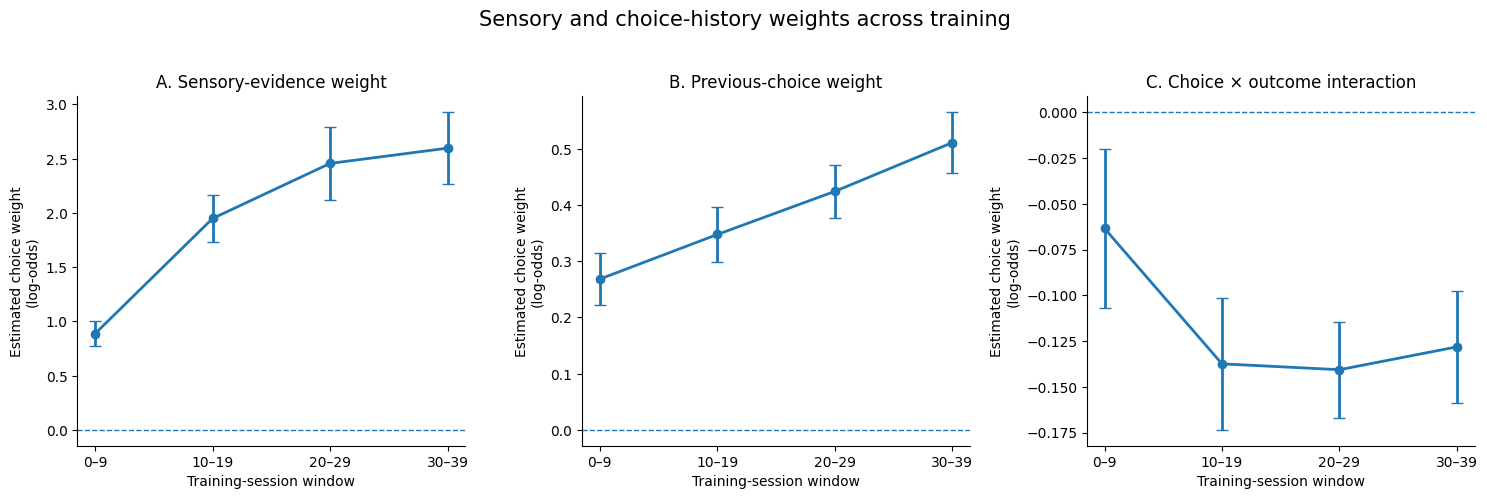

In [87]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.8),
    sharex=True
)

window_positions = np.arange(
    len(session_window_order)
)

panel_information = [
    (
        axes[0],
        "signed_contrast_right",
        "A. Sensory-evidence weight"
    ),
    (
        axes[1],
        "previous_choice_signed",
        "B. Previous-choice weight"
    ),
    (
        axes[2],
        "previous_choice_signed:previous_outcome_signed",
        "C. Choice × outcome interaction"
    )
]

for axis, term, title in panel_information:

    term_data = (
        window_coefficients_df.loc[
            window_coefficients_df["term"] == term
        ]
        .sort_values("session_window")
    )

    coefficient = term_data[
        "coefficient"
    ].to_numpy()

    lower_error = (
        coefficient
        - term_data["lower_ci"].to_numpy()
    )

    upper_error = (
        term_data["upper_ci"].to_numpy()
        - coefficient
    )

    axis.errorbar(
        window_positions,
        coefficient,
        yerr=[
            lower_error,
            upper_error
        ],
        marker="o",
        linewidth=2,
        capsize=4
    )

    axis.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    axis.set_title(title)

    axis.set_xticks(window_positions)

    axis.set_xticklabels(
        [
            "0–9",
            "10–19",
            "20–29",
            "30–39"
        ]
    )

    axis.set_xlabel(
        "Training-session window"
    )

    axis.set_ylabel(
        "Estimated choice weight\n(log-odds)"
    )

    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

    # Optional: display significance against zero
    for position, (_, row) in enumerate(
        term_data.iterrows()
    ):

        if row["p_value"] < 0.001:
            p_label = "p<0.001"
        else:
            p_label = f"p={row['p_value']:.3f}"

        vertical_offset = (
            8
            if row["coefficient"] >= 0
            else -15
        )


fig.suptitle(
    "Sensory and choice-history weights across training",
    fontsize=15,
    y=1.03
)

plt.tight_layout()
plt.show()

In [90]:
reward_window_data = (
    training_mice_session_df.loc[
        training_mice_session_df[
            "training_session"
        ].between(0, 39)
    ]
    .copy()
)

reward_window_data["session_window"] = pd.cut(
    reward_window_data["training_session"],
    bins=[-1, 9, 19, 29, 39],
    labels=session_window_order,
    ordered=True
)

# First average within each mouse and window
mouse_reward_by_window = (
    reward_window_data
    .groupby(
        ["subject", "session_window"],
        observed=True,
        as_index=False
    )
    .agg(
        mean_reward_per_trial=(
            "mean_reward",
            "mean"
        )
    )
)

# Then calculate population mean and SEM across mice
reward_window_summary = (
    mouse_reward_by_window
    .groupby(
        "session_window",
        observed=True,
        as_index=False
    )
    .agg(
        mean_reward=(
            "mean_reward_per_trial",
            "mean"
        ),
        sem_reward=(
            "mean_reward_per_trial",
            "sem"
        ),
        n_mice=(
            "subject",
            "nunique"
        )
    )
)

reward_window_summary["session_window"] = pd.Categorical(
    reward_window_summary["session_window"],
    categories=session_window_order,
    ordered=True
)

reward_window_summary = (
    reward_window_summary
    .sort_values("session_window")
)

display(reward_window_summary)

,session_window,mean_reward,sem_reward,n_mice
0,Sessions 0–9,1.653086,0.028994,140
1,Sessions 10–19,1.781615,0.031562,139
2,Sessions 20–29,1.625150,0.043104,132
3,Sessions 30–39,1.484835,0.043019,121


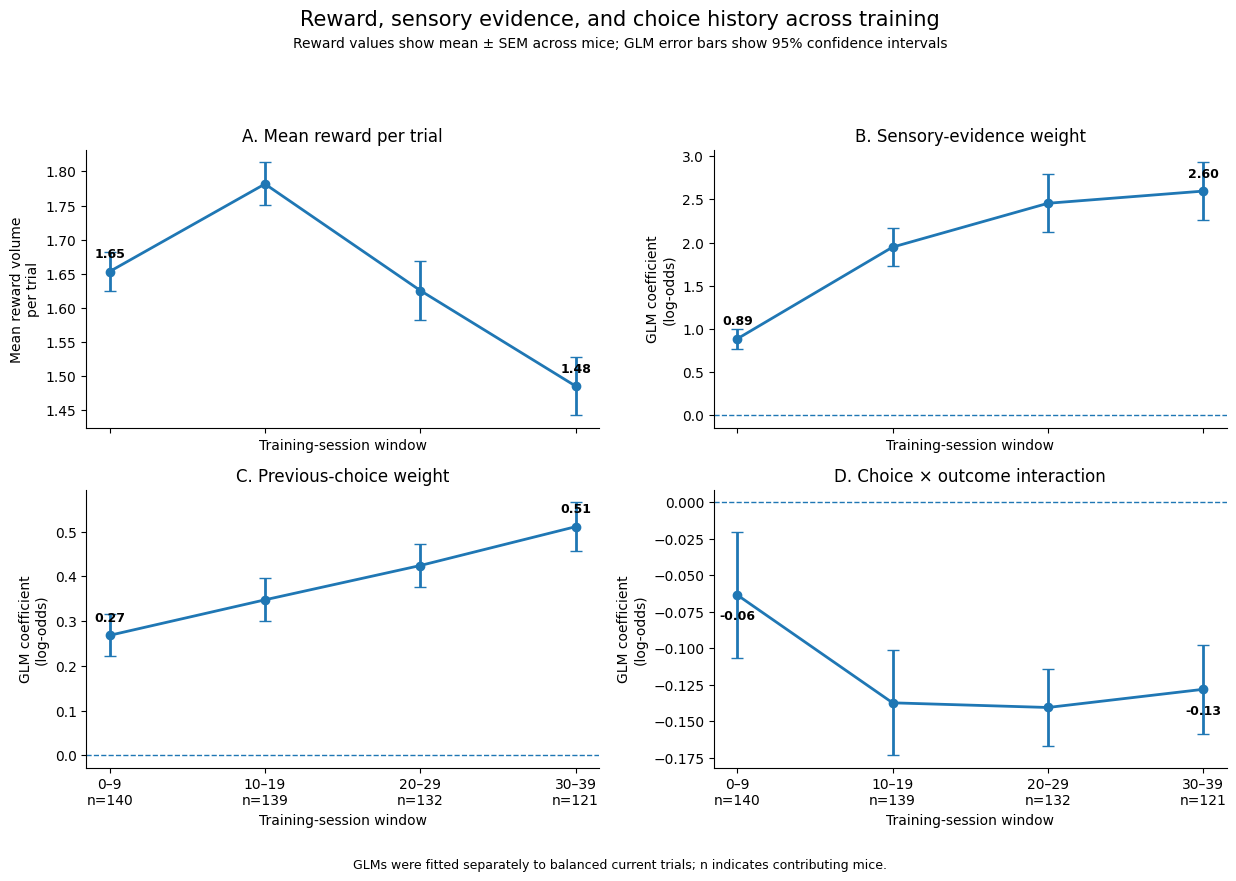

In [91]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12.5, 8.5),
    sharex=True
)

window_positions = np.arange(
    len(session_window_order)
)

# Number of mice in the GLM analysis
glm_sample_sizes = (
    window_history_data
    .groupby(
        "session_window",
        observed=True
    )["subject"]
    .nunique()
    .reindex(session_window_order)
)

window_tick_labels = [
    f"0–9\nn={glm_sample_sizes.iloc[0]}",
    f"10–19\nn={glm_sample_sizes.iloc[1]}",
    f"20–29\nn={glm_sample_sizes.iloc[2]}",
    f"30–39\nn={glm_sample_sizes.iloc[3]}"
]

# --------------------------------------------------
# Panel A: mean reward per trial
# --------------------------------------------------

reward_axis = axes[0, 0]

reward_values = (
    reward_window_summary["mean_reward"]
    .to_numpy()
)

reward_errors = (
    reward_window_summary["sem_reward"]
    .to_numpy()
)

reward_axis.errorbar(
    window_positions,
    reward_values,
    yerr=reward_errors,
    marker="o",
    linewidth=2,
    capsize=4
)

# Label first and final reward values
for position in [0, len(reward_values) - 1]:

    reward_axis.annotate(
        f"{reward_values[position]:.2f}",
        (
            position,
            reward_values[position]
        ),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

reward_axis.set_title(
    "A. Mean reward per trial"
)

reward_axis.set_ylabel(
    "Mean reward volume\nper trial"
)

# --------------------------------------------------
# Panels B–D: GLM coefficients
# --------------------------------------------------

glm_panels = [
    (
        axes[0, 1],
        "signed_contrast_right",
        "B. Sensory-evidence weight"
    ),
    (
        axes[1, 0],
        "previous_choice_signed",
        "C. Previous-choice weight"
    ),
    (
        axes[1, 1],
        "previous_choice_signed:previous_outcome_signed",
        "D. Choice × outcome interaction"
    )
]

for axis, term, title in glm_panels:

    term_data = (
        window_coefficients_df.loc[
            window_coefficients_df["term"] == term
        ]
        .sort_values("session_window")
    )

    coefficient = (
        term_data["coefficient"]
        .to_numpy()
    )

    lower_error = (
        coefficient
        - term_data["lower_ci"].to_numpy()
    )

    upper_error = (
        term_data["upper_ci"].to_numpy()
        - coefficient
    )

    axis.errorbar(
        window_positions,
        coefficient,
        yerr=[
            lower_error,
            upper_error
        ],
        marker="o",
        linewidth=2,
        capsize=4
    )

    axis.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    # Label first and final coefficients
    for position in [0, len(coefficient) - 1]:

        value = coefficient[position]

        vertical_offset = (
            10 if value >= 0
            else -18
        )

        axis.annotate(
            f"{value:.2f}",
            (
                position,
                value
            ),
            textcoords="offset points",
            xytext=(
                0,
                vertical_offset
            ),
            ha="center",
            fontsize=9,
            fontweight="bold"
        )

    axis.set_title(title)

    axis.set_ylabel(
        "GLM coefficient\n(log-odds)"
    )

# --------------------------------------------------
# Shared formatting
# --------------------------------------------------

for axis in axes.flat:

    axis.set_xticks(
        window_positions
    )

    axis.set_xticklabels(
        window_tick_labels
    )

    axis.set_xlabel(
        "Training-session window"
    )

    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

fig.suptitle(
    "Reward, sensory evidence, and choice history "
    "across training",
    fontsize=15,
    y=1.02
)

fig.text(
    0.5,
    0.975,
    (
        "Reward values show mean ± SEM across mice; "
        "GLM error bars show 95% confidence intervals"
    ),
    ha="center",
    fontsize=10
)

fig.text(
    0.5,
    0.01,
    (
        "GLMs were fitted separately to balanced current trials; "
        "n indicates contributing mice."
    ),
    ha="center",
    fontsize=9
)

plt.tight_layout(
    rect=[0, 0.04, 1, 0.94]
)

plt.show()

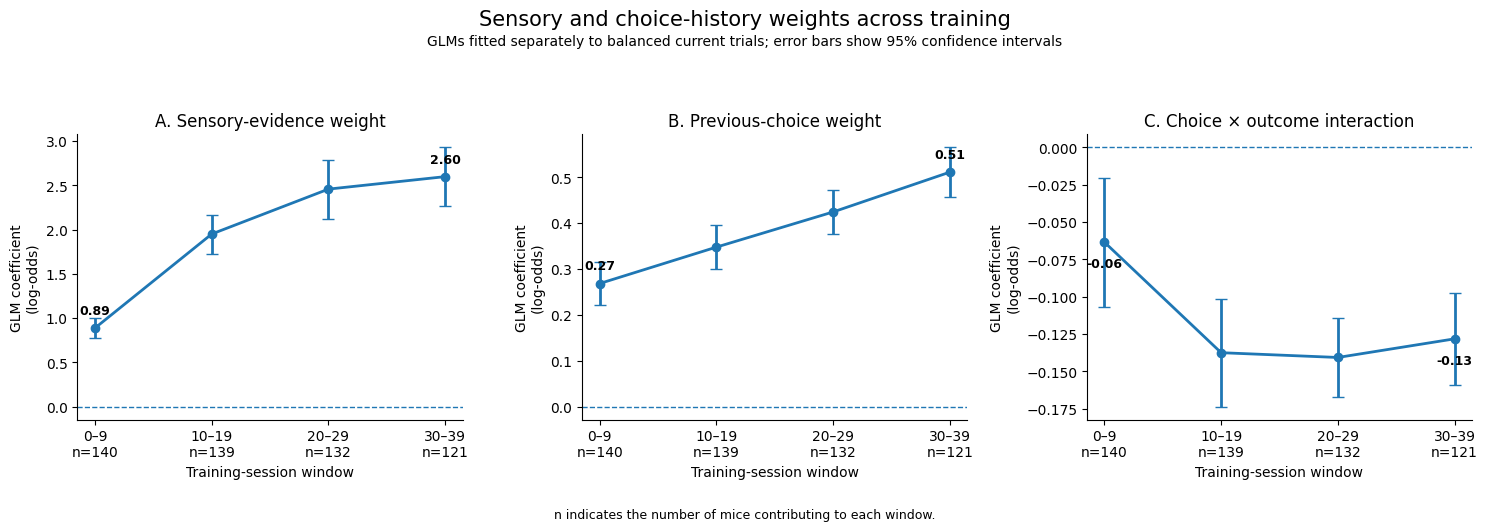

In [89]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.8),
    sharex=True
)

window_positions = np.arange(
    len(session_window_order)
)

# Number of mice contributing to each session window
sample_sizes = (
    window_history_data
    .groupby(
        "session_window",
        observed=True
    )["subject"]
    .nunique()
    .reindex(session_window_order)
)

window_tick_labels = [
    f"0–9\nn={sample_sizes.iloc[0]}",
    f"10–19\nn={sample_sizes.iloc[1]}",
    f"20–29\nn={sample_sizes.iloc[2]}",
    f"30–39\nn={sample_sizes.iloc[3]}"
]

panel_information = [
    (
        axes[0],
        "signed_contrast_right",
        "A. Sensory-evidence weight"
    ),
    (
        axes[1],
        "previous_choice_signed",
        "B. Previous-choice weight"
    ),
    (
        axes[2],
        "previous_choice_signed:previous_outcome_signed",
        "C. Choice × outcome interaction"
    )
]

for axis, term, title in panel_information:

    term_data = (
        window_coefficients_df.loc[
            window_coefficients_df["term"] == term
        ]
        .sort_values("session_window")
    )

    coefficient = (
        term_data["coefficient"]
        .to_numpy()
    )

    lower_error = (
        coefficient
        - term_data["lower_ci"].to_numpy()
    )

    upper_error = (
        term_data["upper_ci"].to_numpy()
        - coefficient
    )

    axis.errorbar(
        window_positions,
        coefficient,
        yerr=[
            lower_error,
            upper_error
        ],
        marker="o",
        linewidth=2,
        capsize=4
    )

    # Zero-effect reference line
    axis.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    # Label only the first and final coefficient
    for position in [0, len(coefficient) - 1]:

        value = coefficient[position]

        vertical_offset = (
            10 if value >= 0
            else -18
        )

        axis.annotate(
            f"{value:.2f}",
            (
                position,
                value
            ),
            textcoords="offset points",
            xytext=(
                0,
                vertical_offset
            ),
            ha="center",
            fontsize=9,
            fontweight="bold"
        )

    axis.set_title(
        title,
        fontsize=12
    )

    axis.set_xticks(
        window_positions
    )

    axis.set_xticklabels(
        window_tick_labels
    )

    axis.set_xlabel(
        "Training-session window"
    )

    axis.set_ylabel(
        "GLM coefficient\n(log-odds)"
    )

    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

fig.suptitle(
    "Sensory and choice-history weights across training",
    fontsize=15,
    y=1.04
)

fig.text(
    0.5,
    0.965,
    (
        "GLMs fitted separately to balanced current trials; "
        "error bars show 95% confidence intervals"
    ),
    ha="center",
    fontsize=10
)

fig.text(
    0.5,
    -0.02,
    "n indicates the number of mice contributing to each window.",
    ha="center",
    fontsize=9
)

plt.tight_layout(
    rect=[0, 0.03, 1, 0.93]
)

plt.show()

In [88]:
for axis, (term, title) in zip(
    axes,
    panel_information
):

    term_data = (
        window_coefficients_df.loc[
            window_coefficients_df["term"] == term
        ]
        .sort_values("session_window")
    )

    coefficient = term_data["coefficient"].to_numpy()

    lower_error = (
        coefficient
        - term_data["lower_ci"].to_numpy()
    )

    upper_error = (
        term_data["upper_ci"].to_numpy()
        - coefficient
    )

    axis.errorbar(
        window_positions,
        coefficient,
        yerr=[lower_error, upper_error],
        marker="o",
        linewidth=2,
        capsize=4
    )

    axis.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    # Label only the first and last coefficients
    for position in [0, len(coefficient) - 1]:
        value = coefficient[position]

        vertical_offset = 10 if value >= 0 else -18

        axis.annotate(
            f"{value:.2f}",
            (position, value),
            textcoords="offset points",
            xytext=(0, vertical_offset),
            ha="center",
            fontsize=9,
            fontweight="bold"
        )

    axis.set_title(title)
    axis.set_ylabel(
        "GLM coefficient\n(log-odds)"
    )

ValueError: too many values to unpack (expected 2)

In [79]:
# One row per mouse × session
all_in_training_sessions = (
    training_mice_session_df.loc[
        training_mice_session_df["training_status"] == "in training"
    ]
    .sort_values(["subject", "session_start_time"])
    .copy()
)

# Session number within the in-training period for each mouse
all_in_training_sessions["in_training_session_number"] = (
    all_in_training_sessions
    .groupby("subject")
    .cumcount()
)

# Total number of in-training sessions for each mouse
all_in_training_sessions["n_in_training_sessions"] = (
    all_in_training_sessions
    .groupby("subject")["session"]
    .transform("size")
)

# Relative progress from 0 at the first session
# to 1 at the final in-training session
all_in_training_sessions["relative_training_progress"] = np.where(
    all_in_training_sessions["n_in_training_sessions"] > 1,
    (
        all_in_training_sessions["in_training_session_number"]
        / (
            all_in_training_sessions["n_in_training_sessions"]
            - 1
        )
    ),
    0
)

# Divide the entire training trajectory into four stages
stage_order = [
    "Early\n0–25%",
    "Early-middle\n25–50%",
    "Late-middle\n50–75%",
    "Late\n75–100%"
]

all_in_training_sessions["training_stage"] = pd.cut(
    all_in_training_sessions["relative_training_progress"],
    bins=[-0.001, 0.25, 0.50, 0.75, 1.001],
    labels=stage_order,
    include_lowest=True,
    ordered=True
)

display(
    all_in_training_sessions[
        [
            "subject",
            "session",
            "in_training_session_number",
            "n_in_training_sessions",
            "relative_training_progress",
            "training_stage"
        ]
    ].head(20)
)

,subject,session,in_training_session_number,n_in_training_sessions,relative_training_progress,training_stage
0,CSHL045,b117ed10-6871-42b3-9193-ca708dac4353,0,39,0.000000,Early\n0–25%
1,CSHL045,21875afb-0b62-4bf5-8879-3debc418dc1e,1,39,0.026316,Early\n0–25%
2,CSHL045,ac6a2e48-d78f-4f39-bc3a-bfe8939fd1e4,2,39,0.052632,Early\n0–25%
3,CSHL045,5f64921c-d5a2-4bc1-a230-9709cdc83c80,3,39,0.078947,Early\n0–25%
4,CSHL045,69691324-fa50-4b37-b004-db6110e7e62a,4,39,0.105263,Early\n0–25%
5,CSHL045,8678307d-8821-4335-9548-d11a66e8e824,5,39,0.131579,Early\n0–25%
6,CSHL045,2ec0d1a6-e14d-4340-948a-95bb915333c6,6,39,0.157895,Early\n0–25%
7,CSHL045,473e9e0e-6cf3-4ce3-9ab2-7757bb318bd2,7,39,0.184211,Early\n0–25%
8,CSHL045,33fb9c52-db93-4e07-b74c-ac5e9b4d17ab,8,39,0.210526,Early\n0–25%
9,CSHL045,9344e1a6-c14c-4598-98b7-56eb60f68b40,9,39,0.236842,Early\n0–25%


In [80]:



training_stage_keys = (
    all_in_training_sessions[
        [
            "subject",
            "session",
            "in_training_session_number",
            "relative_training_progress",
            "training_stage"
        ]
    ]
    .drop_duplicates(
        subset=["subject", "session"]
    )
)

history_across_training = (
    trained_trials
    .merge(
        training_stage_keys,
        on=["subject", "session"],
        how="inner"
    )
    .sort_values(
        [
            "subject",
            "session",
            "intervals_0"
        ]
    )
    .copy()
)

print(
    "Trial rows from all in-training sessions:",
    len(history_across_training)
)

print(
    "Number of mice:",
    history_across_training["subject"].nunique()
)

Trial rows from all in-training sessions: 1382935
Number of mice: 139


In [82]:
current_trial_balanced = np.isclose(
    history_across_training[
        "probabilityLeft"
    ].astype(float),
    0.5,
    atol=1e-6
)

valid_current_choice = (
    history_across_training["choice"]
    .isin([-1, 1])
)

valid_previous_choice = (
    history_across_training["previous_choice"]
    .isin([-1, 1])
)

valid_previous_feedback = (
    history_across_training["previous_feedback"]
    .isin([-1, 1])
)

all_training_history_data = (
    history_across_training.loc[
        current_trial_balanced
        & valid_current_choice
        & valid_previous_choice
        & valid_previous_feedback
        & history_across_training[
            "training_stage"
        ].notna()
    ]
    .copy()
)

print(
    "Balanced current trials:",
    len(all_training_history_data)
)

print(
    "Mice:",
    all_training_history_data[
        "subject"
    ].nunique()
)

KeyError: 'previous_choice'

In [83]:
# Current choice:
# 1 = right, 0 = left
all_training_history_data[
    "current_choice_right"
] = (
    all_training_history_data["choice"] == -1
).astype(int)

# Previous choice:
# +1 = right, -1 = left
all_training_history_data[
    "previous_choice_signed"
] = np.where(
    all_training_history_data[
        "previous_choice"
    ] == -1,
    1,
    -1
)

# Previous outcome:
# +1 = rewarded/correct, -1 = error
all_training_history_data[
    "previous_outcome_signed"
] = np.where(
    all_training_history_data[
        "previous_feedback"
    ] == 1,
    1,
    -1
)

# Current sensory evidence:
# positive = rightward evidence
all_training_history_data[
    "signed_contrast_right"
] = (
    all_training_history_data[
        "contrastRight"
    ].fillna(0)
    - all_training_history_data[
        "contrastLeft"
    ].fillna(0)
)

NameError: name 'all_training_history_data' is not defined

In [84]:
stage_sample_summary = (
    all_training_history_data
    .groupby(
        "training_stage",
        observed=True
    )
    .agg(
        n_trials=(
            "current_choice_right",
            "size"
        ),
        n_mice=(
            "subject",
            "nunique"
        ),
        n_sessions=(
            "session",
            "nunique"
        )
    )
    .reset_index()
)

display(stage_sample_summary)

NameError: name 'all_training_history_data' is not defined

In [85]:
model_terms = [
    "signed_contrast_right",
    "previous_choice_signed",
    "previous_choice_signed:previous_outcome_signed"
]

stage_model_results = []

for training_stage in stage_order:

    stage_data = all_training_history_data.loc[
        all_training_history_data[
            "training_stage"
        ].astype(str) == training_stage
    ].copy()

    n_trials = len(stage_data)
    n_mice = stage_data["subject"].nunique()

    print(
        training_stage.replace("\n", " "),
        "| trials:",
        n_trials,
        "| mice:",
        n_mice
    )

    if n_trials < 100 or n_mice < 3:
        print("Skipped because of insufficient data.")
        continue

    stage_model = smf.glm(
        """
        current_choice_right
        ~ signed_contrast_right
        + previous_choice_signed
        + previous_outcome_signed
        + previous_choice_signed:previous_outcome_signed
        """,
        data=stage_data,
        family=sm.families.Binomial()
    ).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": stage_data["subject"]
        }
    )

    confidence_intervals = stage_model.conf_int()

    for term in model_terms:

        stage_model_results.append({
            "training_stage":
                training_stage,

            "term":
                term,

            "coefficient":
                stage_model.params[term],

            "lower_ci":
                confidence_intervals.loc[
                    term,
                    0
                ],

            "upper_ci":
                confidence_intervals.loc[
                    term,
                    1
                ],

            "p_value":
                stage_model.pvalues[term],

            "n_trials":
                n_trials,

            "n_mice":
                n_mice
        })

stage_coefficients_df = pd.DataFrame(
    stage_model_results
)

stage_coefficients_df["training_stage"] = pd.Categorical(
    stage_coefficients_df["training_stage"],
    categories=stage_order,
    ordered=True
)

stage_coefficients_df = (
    stage_coefficients_df
    .sort_values(
        ["term", "training_stage"]
    )
    .reset_index(drop=True)
)

display(stage_coefficients_df)

NameError: name 'all_training_history_data' is not defined

NameError: name 'stage_coefficients_df' is not defined

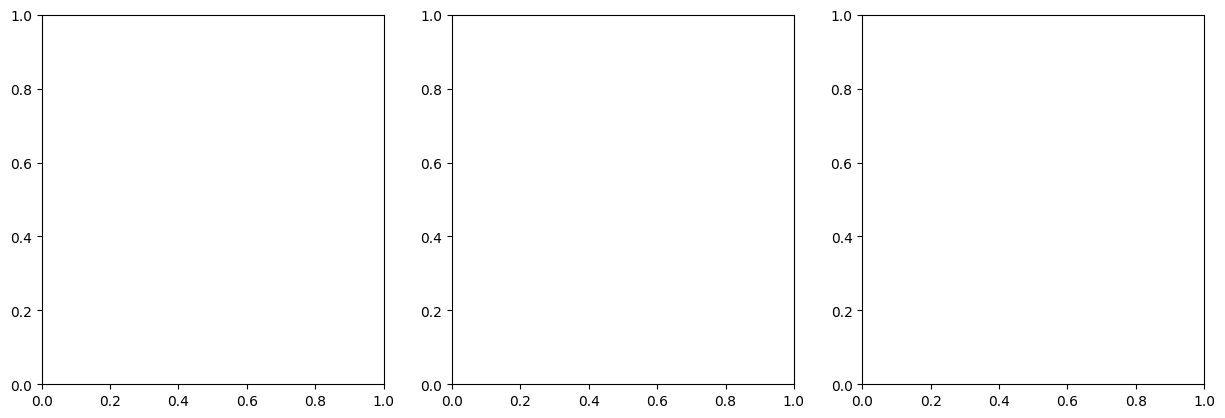

In [86]:

term_labels = {
    "signed_contrast_right":
        "Sensory-evidence weight",

    "previous_choice_signed":
        "Previous-choice weight",

    "previous_choice_signed:previous_outcome_signed":
        "Choice × outcome interaction"
}

panel_information = [
    (
        "signed_contrast_right",
        "A. Sensory-evidence weight"
    ),
    (
        "previous_choice_signed",
        "B. Previous-choice persistence"
    ),
    (
        "previous_choice_signed:previous_outcome_signed",
        "C. Choice × previous outcome"
    )
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.8),
    sharex=True
)

stage_positions = np.arange(
    len(stage_order)
)

for axis, (term, title) in zip(
    axes,
    panel_information
):

    term_data = (
        stage_coefficients_df.loc[
            stage_coefficients_df["term"] == term
        ]
        .sort_values("training_stage")
    )

    coefficient = (
        term_data["coefficient"]
        .to_numpy()
    )

    lower_error = (
        coefficient
        - term_data["lower_ci"].to_numpy()
    )

    upper_error = (
        term_data["upper_ci"].to_numpy()
        - coefficient
    )

    axis.errorbar(
        stage_positions[:len(term_data)],
        coefficient,
        yerr=[
            lower_error,
            upper_error
        ],
        marker="o",
        linewidth=2,
        capsize=4
    )

    axis.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    axis.set_title(title)

    axis.set_xticks(stage_positions)

    axis.set_xticklabels(
        stage_order
    )

    axis.set_xlabel(
        "Relative training stage"
    )

    axis.set_ylabel(
        "Estimated choice weight\n(log-odds)"
    )

    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

fig.suptitle(
    "Sensory and choice-history effects "
    "across the complete training period",
    fontsize=15,
    y=1.03
)

plt.tight_layout()
plt.show()

In [92]:
history_across_training["previous_reward_volume"] = (
    history_across_training
    .groupby(
        ["subject", "session"]
    )["rewardVolume"]
    .shift(1)
)

In [93]:
history_across_training["previous_choice"] = (
    history_across_training
    .groupby(["subject", "session"])["choice"]
    .shift(1)
)

history_across_training["previous_feedback"] = (
    history_across_training
    .groupby(["subject", "session"])["feedbackType"]
    .shift(1)
)

history_across_training["previous_reward_volume"] = (
    history_across_training
    .groupby(["subject", "session"])["rewardVolume"]
    .shift(1)
)

In [94]:
valid_previous_reward_volume = (
    history_across_training[
        "previous_reward_volume"
    ].notna()
)

In [96]:
window_history_data = (
    history_across_training.loc[
        current_trial_balanced
        & valid_current_choice
        & valid_previous_choice
        & valid_previous_feedback
        & valid_previous_reward_volume
        & history_across_training[
            "session"
        ].notna()
    ]
    .copy()
)

In [97]:
# Was the previous trial rewarded?
# +1 = rewarded
# -1 = unrewarded
window_history_data[
    "previous_rewarded_signed"
] = np.where(
    window_history_data[
        "previous_reward_volume"
    ] > 0,
    1,
    -1
)

# Reward size is standardized only among rewarded trials.
rewarded_previous_trials = (
    window_history_data[
        "previous_reward_volume"
    ] > 0
)

mean_reward_size = (
    window_history_data.loc[
        rewarded_previous_trials,
        "previous_reward_volume"
    ]
    .mean()
)

standard_deviation_reward_size = (
    window_history_data.loc[
        rewarded_previous_trials,
        "previous_reward_volume"
    ]
    .std()
)

window_history_data[
    "previous_reward_size_z"
] = 0.0

window_history_data.loc[
    rewarded_previous_trials,
    "previous_reward_size_z"
] = (
    window_history_data.loc[
        rewarded_previous_trials,
        "previous_reward_volume"
    ]
    - mean_reward_size
) / standard_deviation_reward_size

In [98]:
window_model = smf.glm(
    """
    current_choice_right
    ~ signed_contrast_right
    + previous_choice_signed
    + previous_rewarded_signed
    + previous_reward_size_z
    + previous_choice_signed:previous_rewarded_signed
    + previous_choice_signed:previous_reward_size_z
    """,
    data=window_data,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": window_data["subject"]
    }
)

PatsyError: Error evaluating factor: NameError: name 'previous_reward_size_z' is not defined
    current_choice_right     ~ signed_contrast_right     + previous_choice_signed     + previous_rewarded_signed     + previous_reward_size_z     + previous_choice_signed:previous_rewarded_signed     + previous_choice_signed:previous_reward_size_z
                                                                                                                       ^^^^^^^^^^^^^^^^^^^^^^

In [ ]:
model_terms = [
    "signed_contrast_right",
    "previous_choice_signed",
    "previous_choice_signed:previous_rewarded_signed",
    "previous_choice_signed:previous_reward_size_z"
]

In [99]:
term_labels = {
    "signed_contrast_right":
        "Sensory-evidence weight",

    "previous_choice_signed":
        "Previous-choice weight",

    "previous_choice_signed:previous_rewarded_signed":
        "Reward occurrence × previous choice",

    "previous_choice_signed:previous_reward_size_z":
        "Reward size × previous choice"
}

In [110]:
# ============================================================
# Use the existing in-training session numbering
# ============================================================

required_columns = [
    "subject",
    "session",
    "intervals_0",
    "in_training_session_number",
    "training_status"
]

missing_columns = [
    column
    for column in required_columns
    if column not in history_across_training.columns
]

if missing_columns:
    raise KeyError(
        "history_across_training is missing: "
        + ", ".join(missing_columns)
    )

# history_across_training was already created from sessions
# labelled "in training", with session numbers starting at 0
# separately for every mouse.
reward_glm_data = (
    history_across_training.loc[
        history_across_training[
            "in_training_session_number"
        ].between(0, 39)
    ]
    .sort_values(
        ["subject", "session", "intervals_0"]
    )
    .copy()
)

# Define four windows from the EXISTING in-training number
reward_glm_data["session_window_index"] = (
    reward_glm_data[
        "in_training_session_number"
    ] // 10
).astype(int)

window_label_map = {
    0: "0–9",
    1: "10–19",
    2: "20–29",
    3: "30–39"
}

reward_glm_data["session_window"] = (
    reward_glm_data[
        "session_window_index"
    ].map(window_label_map)
)

session_window_order = [0, 1, 2, 3]

# ============================================================
# Session-level sanity check
# ============================================================

session_window_check = (
    reward_glm_data[
        [
            "subject",
            "session",
            "training_status",
            "in_training_session_number",
            "session_window_index",
            "session_window"
        ]
    ]
    .drop_duplicates(
        subset=["subject", "session"]
    )
    .sort_values(
        ["subject", "in_training_session_number"]
    )
)

display(session_window_check.head(60))

print("\nTraining-status values included:")
print(
    session_window_check[
        "training_status"
    ].value_counts(dropna=False)
)

print("\nNumber of mouse-sessions per window:")
print(
    session_window_check[
        "session_window"
    ]
    .value_counts()
    .reindex(
        ["0–9", "10–19", "20–29", "30–39"]
    )
)

print("\nNumber of mice per window:")
print(
    session_window_check
    .groupby("session_window")["subject"]
    .nunique()
    .reindex(
        ["0–9", "10–19", "20–29", "30–39"]
    )
)

,subject,session,training_status,in_training_session_number,session_window_index,session_window
0,CSHL045,b117ed10-6871-42b3-9193-ca708dac4353,in training,0,0,0–9
282,CSHL045,21875afb-0b62-4bf5-8879-3debc418dc1e,in training,1,0,0–9
551,CSHL045,ac6a2e48-d78f-4f39-bc3a-bfe8939fd1e4,in training,2,0,0–9
866,CSHL045,5f64921c-d5a2-4bc1-a230-9709cdc83c80,in training,3,0,0–9
1237,CSHL045,69691324-fa50-4b37-b004-db6110e7e62a,in training,4,0,0–9
1708,CSHL045,8678307d-8821-4335-9548-d11a66e8e824,in training,5,0,0–9
2273,CSHL045,2ec0d1a6-e14d-4340-948a-95bb915333c6,in training,6,0,0–9
2864,CSHL045,473e9e0e-6cf3-4ce3-9ab2-7757bb318bd2,in training,7,0,0–9
3441,CSHL045,33fb9c52-db93-4e07-b74c-ac5e9b4d17ab,in training,8,0,0–9
4232,CSHL045,9344e1a6-c14c-4598-98b7-56eb60f68b40,in training,9,0,0–9



Training-status values included:
training_status
in training    2376
Name: count, dtype: int64

Number of mouse-sessions per window:
session_window
0–9      1265
10–19     670
20–29     305
30–39     136
Name: count, dtype: int64

Number of mice per window:
session_window
0–9      139
10–19     93
20–29     41
30–39     20
Name: subject, dtype: int64


In [111]:
session_window_check["training_status"].value_counts()

,count
training_status,
in training,2376


0–9 | trials: 418082 | mice: 139
10–19 | trials: 338430 | mice: 93
20–29 | trials: 184254 | mice: 41
30–39 | trials: 85966 | mice: 20


,session_window,term,coefficient,lower_ci,upper_ci,p_value,n_trials,n_mice
0,0–9,previous_choice_signed,0.273193,0.219350,0.327035,2.659293e-23,418082,139
1,10–19,previous_choice_signed,0.331463,0.281991,0.380935,2.167193e-39,338430,93
2,20–29,previous_choice_signed,0.419303,0.327078,0.511529,5.057036e-19,184254,41
3,30–39,previous_choice_signed,0.544367,0.419812,0.668922,1.071252e-17,85966,20
4,0–9,previous_choice_signed:previous_outcome_signed,-0.059237,-0.108048,-0.010427,1.737609e-02,418082,139
5,10–19,previous_choice_signed:previous_outcome_signed,-0.126507,-0.171025,-0.081989,2.552862e-08,338430,93
6,20–29,previous_choice_signed:previous_outcome_signed,-0.151827,-0.208640,-0.095014,1.625121e-07,184254,41
7,30–39,previous_choice_signed:previous_outcome_signed,-0.163580,-0.243869,-0.083291,6.518237e-05,85966,20
8,0–9,previous_choice_signed:previous_reward_size_z,0.049976,0.029060,0.070891,2.825129e-06,418082,139
9,10–19,previous_choice_signed:previous_reward_size_z,0.036506,0.010722,0.062289,5.519537e-03,338430,93


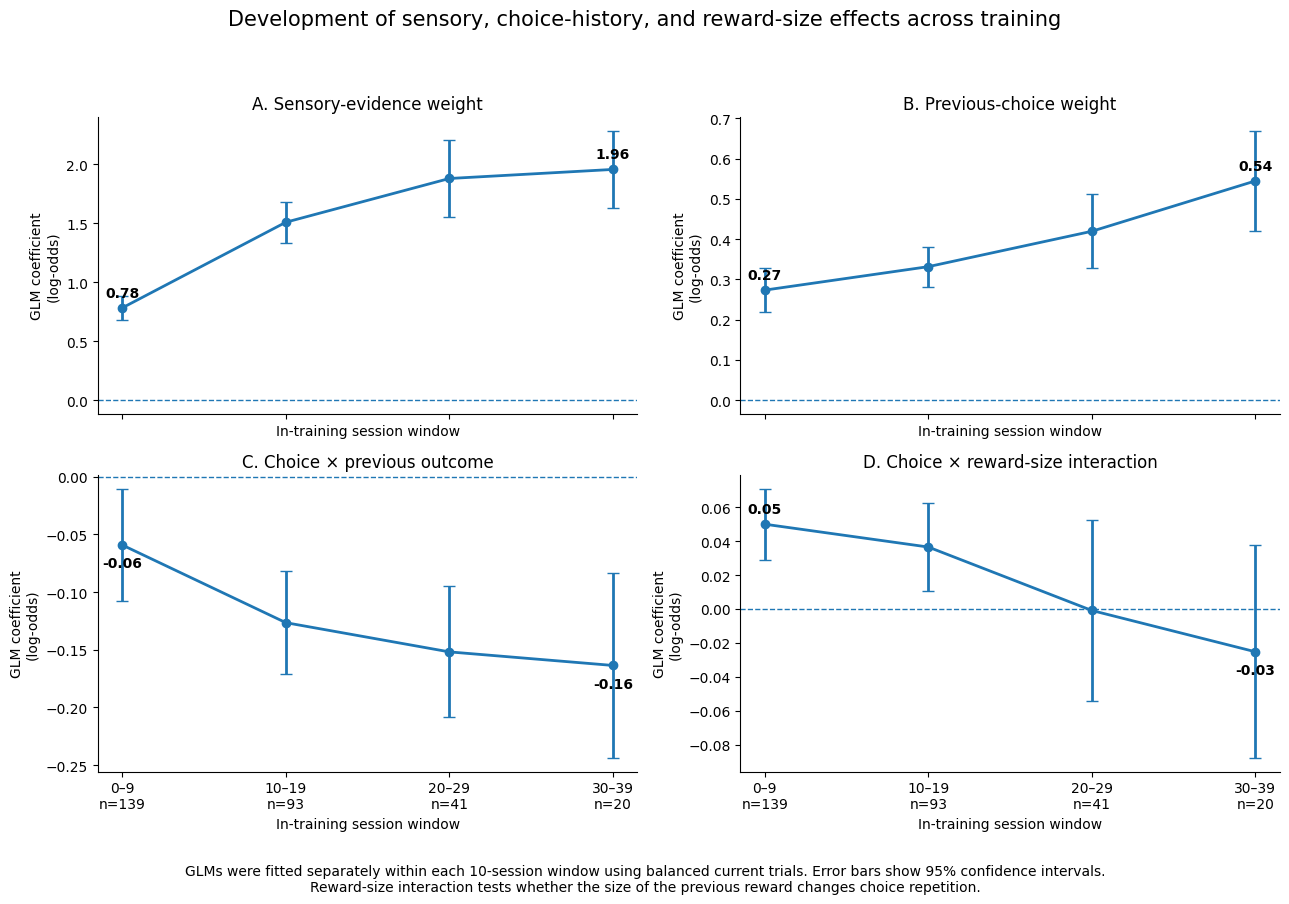

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ============================================================
# 1. Start from the corrected in-training trial-level data
# ============================================================

glm_data = (
    reward_glm_data
    .sort_values(
        ["subject", "session", "intervals_0"]
    )
    .copy()
)

required_columns = [
    "subject",
    "session",
    "intervals_0",
    "choice",
    "feedbackType",
    "rewardVolume",
    "contrastLeft",
    "contrastRight",
    "probabilityLeft",
    "session_window"
]

missing_columns = [
    column
    for column in required_columns
    if column not in glm_data.columns
]

if missing_columns:
    raise KeyError(
        "reward_glm_data is missing: "
        + ", ".join(missing_columns)
    )

# ============================================================
# 2. Encode current-trial variables
# ============================================================

# Positive values indicate rightward sensory evidence
glm_data["signed_contrast_right"] = (
    glm_data["contrastRight"].fillna(0)
    - glm_data["contrastLeft"].fillna(0)
)

# IBL choice coding:
# choice = -1 means right
# choice = +1 means left
glm_data["current_choice_right"] = np.where(
    glm_data["choice"] == -1,
    1,
    np.where(
        glm_data["choice"] == 1,
        0,
        np.nan
    )
)

# Signed choice used for creating the previous-choice variable:
# right = +1
# left  = -1
glm_data["choice_signed"] = np.where(
    glm_data["choice"] == -1,
    1,
    np.where(
        glm_data["choice"] == 1,
        -1,
        np.nan
    )
)

# ============================================================
# 3. Create previous-trial variables within each session
# ============================================================

group_keys = [
    "subject",
    "session"
]

glm_data["previous_choice_signed"] = (
    glm_data
    .groupby(group_keys)["choice_signed"]
    .shift(1)
)

glm_data["previous_outcome_signed"] = (
    glm_data
    .groupby(group_keys)["feedbackType"]
    .shift(1)
)

glm_data["previous_reward_volume"] = (
    glm_data
    .groupby(group_keys)["rewardVolume"]
    .shift(1)
)

glm_data["current_probability_left"] = (
    glm_data["probabilityLeft"]
    .astype(float)
)

# ============================================================
# 4. Keep balanced-probability current trials
# ============================================================

current_trial_balanced = np.isclose(
    glm_data["current_probability_left"],
    0.5,
    atol=1e-6
)

balanced_glm_data = glm_data.loc[
    current_trial_balanced
].copy()

balanced_glm_data = balanced_glm_data.dropna(
    subset=[
        "current_choice_right",
        "signed_contrast_right",
        "previous_choice_signed",
        "previous_outcome_signed",
        "previous_reward_volume",
        "session_window"
    ]
).copy()

balanced_glm_data = balanced_glm_data.loc[
    balanced_glm_data[
        "previous_choice_signed"
    ].isin([-1, 1])
    & balanced_glm_data[
        "previous_outcome_signed"
    ].isin([-1, 1])
].copy()

# ============================================================
# 5. Fit one GLM per 10-session window
# ============================================================

session_window_order = [
    "0–9",
    "10–19",
    "20–29",
    "30–39"
]

terms_to_plot = [
    "signed_contrast_right",
    "previous_choice_signed",
    "previous_choice_signed:previous_outcome_signed",
    "previous_choice_signed:previous_reward_size_z"
]

term_titles = {
    "signed_contrast_right":
        "A. Sensory-evidence weight",

    "previous_choice_signed":
        "B. Previous-choice weight",

    "previous_choice_signed:previous_outcome_signed":
        "C. Choice × previous outcome",

    "previous_choice_signed:previous_reward_size_z":
        "D. Choice × reward-size interaction"
}

results = []

for window_label in session_window_order:

    window_data = balanced_glm_data.loc[
        balanced_glm_data[
            "session_window"
        ].astype(str) == window_label
    ].copy()

    n_trials = len(window_data)
    n_mice = window_data[
        "subject"
    ].nunique()

    print(
        window_label,
        "| trials:",
        n_trials,
        "| mice:",
        n_mice
    )

    if n_trials < 100 or n_mice < 3:
        print("Skipped: insufficient data.")
        continue

    # --------------------------------------------------------
    # Standardize previous reward size among rewarded
    # previous trials within this session window
    # --------------------------------------------------------

    rewarded_previous_trials = (
        window_data["previous_reward_volume"] > 0
    )

    rewarded_reward_sizes = window_data.loc[
        rewarded_previous_trials,
        "previous_reward_volume"
    ]

    reward_mean = rewarded_reward_sizes.mean()
    reward_std = rewarded_reward_sizes.std()

    if (
        len(rewarded_reward_sizes) < 2
        or not np.isfinite(reward_std)
        or reward_std == 0
    ):
        print(
            "Skipped: insufficient variation "
            "in previous reward size."
        )
        continue

    # Unrewarded previous trials receive zero.
    # Rewarded trials are z-scored within the window.
    window_data["previous_reward_size_z"] = 0.0

    window_data.loc[
        rewarded_previous_trials,
        "previous_reward_size_z"
    ] = (
        window_data.loc[
            rewarded_previous_trials,
            "previous_reward_volume"
        ]
        - reward_mean
    ) / reward_std

    # --------------------------------------------------------
    # Binomial choice GLM
    # --------------------------------------------------------

    formula = """
        current_choice_right
        ~ signed_contrast_right
        + previous_choice_signed
        + previous_outcome_signed
        + previous_reward_size_z
        + previous_choice_signed:previous_outcome_signed
        + previous_choice_signed:previous_reward_size_z
    """

    model = smf.glm(
        formula=formula,
        data=window_data,
        family=sm.families.Binomial()
    ).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": window_data["subject"]
        }
    )

    confidence_intervals = model.conf_int()

    for term in terms_to_plot:

        results.append({
            "session_window": window_label,
            "term": term,
            "coefficient": model.params[term],
            "lower_ci":
                confidence_intervals.loc[term, 0],
            "upper_ci":
                confidence_intervals.loc[term, 1],
            "p_value": model.pvalues[term],
            "n_trials": n_trials,
            "n_mice": n_mice
        })

window_glm_results_df = pd.DataFrame(
    results
)

window_glm_results_df["session_window"] = (
    pd.Categorical(
        window_glm_results_df["session_window"],
        categories=session_window_order,
        ordered=True
    )
)

window_glm_results_df = (
    window_glm_results_df
    .sort_values(
        ["term", "session_window"]
    )
    .reset_index(drop=True)
)

display(window_glm_results_df)

# ============================================================
# 6. Plot the four-panel figure
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9),
    sharex=True
)

axes = axes.flatten()

window_positions = np.arange(
    len(session_window_order)
)

sample_sizes = (
    window_glm_results_df
    .drop_duplicates("session_window")
    .set_index("session_window")["n_mice"]
    .reindex(session_window_order)
)

window_tick_labels = [
    (
        f"{window_label}\n"
        f"n={int(sample_sizes.loc[window_label])}"
    )
    for window_label in session_window_order
]

for axis, term in zip(
    axes,
    terms_to_plot
):

    term_data = (
        window_glm_results_df.loc[
            window_glm_results_df[
                "term"
            ] == term
        ]
        .sort_values("session_window")
        .copy()
    )

    coefficients = (
        term_data["coefficient"]
        .to_numpy()
    )

    lower_error = (
        coefficients
        - term_data["lower_ci"].to_numpy()
    )

    upper_error = (
        term_data["upper_ci"].to_numpy()
        - coefficients
    )

    axis.errorbar(
        window_positions,
        coefficients,
        yerr=[
            lower_error,
            upper_error
        ],
        marker="o",
        linewidth=2,
        capsize=4
    )

    axis.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    axis.set_title(
        term_titles[term]
    )

    axis.set_ylabel(
        "GLM coefficient\n(log-odds)"
    )

    axis.set_xticks(
        window_positions
    )

    axis.set_xticklabels(
        window_tick_labels
    )

    axis.set_xlabel(
        "In-training session window"
    )

    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

    # Label the first and final coefficients
    for position in [
        0,
        len(coefficients) - 1
    ]:

        value = coefficients[position]

        vertical_offset = (
            8 if value >= 0 else -16
        )

        axis.annotate(
            f"{value:.2f}",
            (
                window_positions[position],
                value
            ),
            textcoords="offset points",
            xytext=(
                0,
                vertical_offset
            ),
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

fig.suptitle(
    (
        "Development of sensory, choice-history, "
        "and reward-size effects across training"
    ),
    fontsize=15,
    y=0.99
)

fig.text(
    0.5,
    0.01,
    (
        "GLMs were fitted separately within each "
        "10-session window using balanced current trials. "
        "Error bars show 95% confidence intervals.\n"
        "Reward-size interaction tests whether the size of "
        "the previous reward changes choice repetition."
    ),
    ha="center",
    fontsize=10
)

plt.tight_layout(
    rect=[0, 0.06, 1, 0.95]
)

plt.show()

In [115]:
window_order = ["0–9", "10–19", "20–29", "30–39"]

# 1. Mice with any in-training session in each window
session_level_counts = (
    session_window_check
    .groupby("session_window")["subject"]
    .nunique()
    .reindex(window_order)
    .rename("mice_with_sessions")
)

# 2. Mice remaining after selecting balanced current trials
balanced_trial_counts = (
    glm_data.loc[
        np.isclose(
            glm_data["probabilityLeft"].astype(float),
            0.5,
            atol=1e-6
        )
    ]
    .groupby("session_window")["subject"]
    .nunique()
    .reindex(window_order)
    .rename("mice_with_balanced_trials")
)

# 3. Mice remaining after all GLM validity filters
final_glm_counts = (
    balanced_glm_data
    .groupby("session_window")["subject"]
    .nunique()
    .reindex(window_order)
    .rename("mice_in_final_glm")
)

attrition_summary = pd.concat(
    [
        session_level_counts,
        balanced_trial_counts,
        final_glm_counts
    ],
    axis=1
)

display(attrition_summary)

,mice_with_sessions,mice_with_balanced_trials,mice_in_final_glm
session_window,,,
0–9,139,139,139
10–19,93,93,93
20–29,41,41,41
30–39,20,20,20


In [116]:
mouse_training_lengths = (
    session_window_check
    .groupby("subject")["in_training_session_number"]
    .max()
    .add(1)
    .rename("n_in_training_sessions")
)

print(mouse_training_lengths.describe())

print("\nMice reaching each stage:")
print({
    "at least 10 sessions":
        (mouse_training_lengths >= 10).sum(),

    "at least 20 sessions":
        (mouse_training_lengths >= 20).sum(),

    "at least 30 sessions":
        (mouse_training_lengths >= 30).sum(),

    "at least 40 sessions":
        (mouse_training_lengths >= 40).sum()
})

count    139.000000
mean      17.093525
std       10.311730
min        3.000000
25%        9.000000
50%       14.000000
75%       23.000000
max       39.000000
Name: n_in_training_sessions, dtype: float64

Mice reaching each stage:
{'at least 10 sessions': np.int64(103), 'at least 20 sessions': np.int64(45), 'at least 30 sessions': np.int64(22), 'at least 40 sessions': np.int64(0)}
